<a href="https://colab.research.google.com/github/Tanjila-Hoque/BrainBuzz-Arcade/blob/main/THESIS_ON_UK_3_LACS_DATA.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Installing missing package: catboost ...

LOADING UK ROAD SAFETY DATA — 2017 + 2018

LOADING UK ROAD SAFETY DATA — 2017 + 2018

Dataset files are not visible to this notebook kernel.
Opening the Colab upload dialog...


Saving dataset17,18.zip to dataset17,18.zip

Upload successful. Files found:
  Accidents_2017.csv -> /content/dataset17_18_extracted/Accidents_2017.csv
  Accidents_2018.csv -> /content/dataset17_18_extracted/Accidents_2018.csv
  Vehicles_2017.csv -> /content/dataset17_18_extracted/Vehicles_2017.csv
  Vehicles_2018.csv -> /content/dataset17_18_extracted/Vehicles_2018.csv
  Casualties_2017.csv -> /content/dataset17_18_extracted/Casualties_2017.csv
  Casualties_2018.csv -> /content/dataset17_18_extracted/Casualties_2018.csv
  Accidents_2017.csv -> /content/dataset17_18_extracted/Accidents_2017.csv
  Accidents_2018.csv -> /content/dataset17_18_extracted/Accidents_2018.csv
  Vehicles_2017.csv -> /content/dataset17_18_extracted/Vehicles_2017.csv
  Vehicles_2018.csv -> /content/dataset17_18_extracted/Vehicles_2018.csv
  Casualties_2017.csv -> /content/dataset17_18_extracted/Casualties_2017.csv
  Casualties_2018.csv -> /content/dataset17_18_extracted/Casualties_2018.csv

Dataset files found su

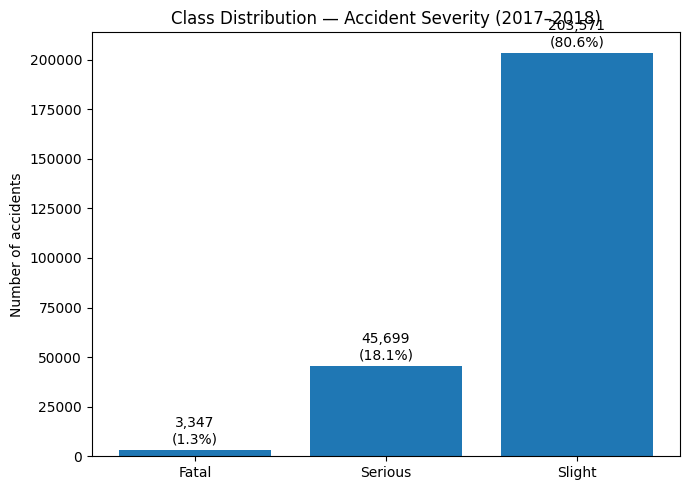

Pool (for CV): (202093, 135)
Untouched test: (50524, 135)
Class weights: {0: 3.5, 1: 1.4877611383019897, 2: 0.563387314728529}

SHAP-BASED FEATURE SELECTION — TOP 30
Feature ranking source: SHAP

Top 30 features:
cas_Casualty_Type_mode                         0.198853
Did_Police_Officer_Attend_Scene_of_Accident    0.114355
veh_Vehicle_Manoeuvre_mode                     0.095551
cas_Age_of_Casualty_max                        0.092705
hour_cos                                       0.061425
rural_x_speed                                  0.057543
casualty_per_vehicle                           0.054705
veh_1st_Point_of_Impact_nunique                0.048957
veh_Vehicle_Leaving_Carriageway_mode           0.048305
urban_x_road                                   0.046914
casualty_x_speed                               0.046882
cas_Sex_of_Casualty_mode                       0.046352
veh_Vehicle_Type_mode                          0.045188
cas_Age_of_Casualty_mean                       0.044222
veh

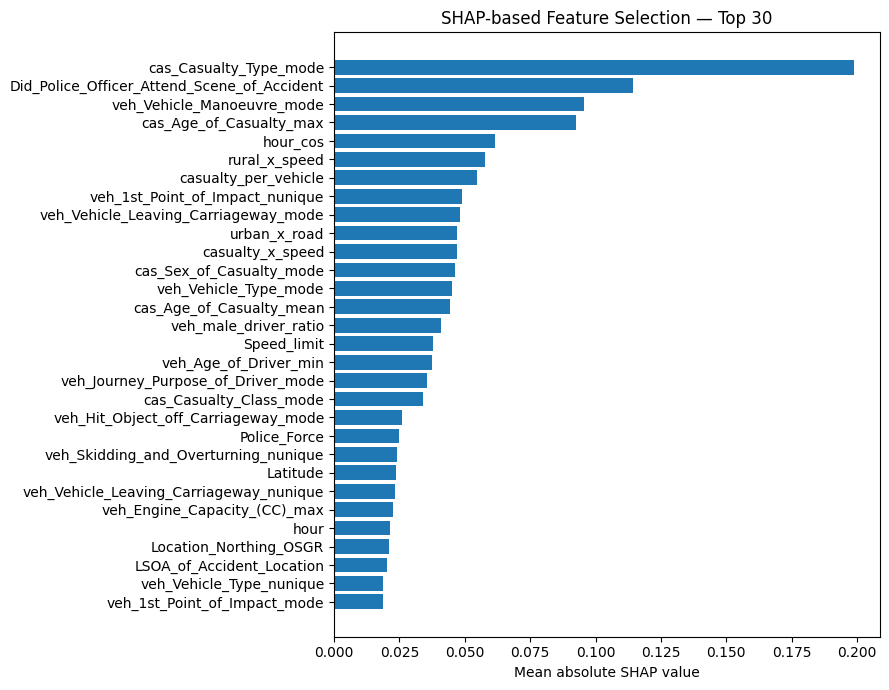


STRATIFIED 5-FOLD CV -> OOF PROBABILITIES
Fold 1/5: macro-F1=0.4775
Fold 2/5: macro-F1=0.4791
Fold 3/5: macro-F1=0.4772
Fold 4/5: macro-F1=0.4711
Fold 5/5: macro-F1=0.4884

Mean CV macro-F1: 0.4787 (+/- 0.0056)
Saved /mnt/data/thesis_outputs_2017_2018/cv_macrof1_per_fold.png


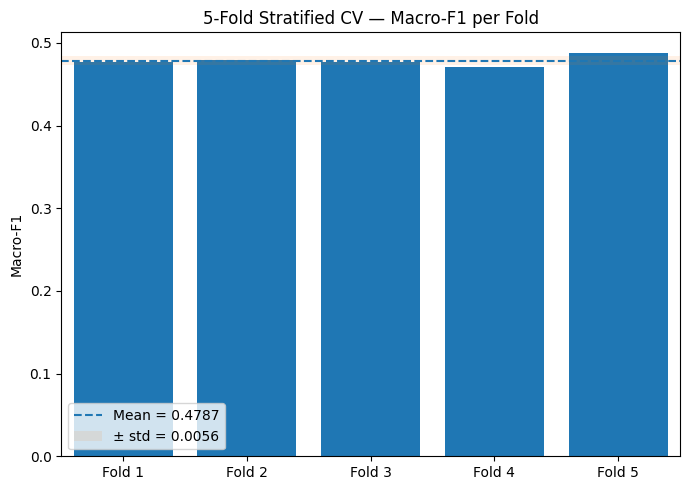


OOF (plain argmax) classification report:
              precision    recall  f1-score   support

       Fatal      0.303     0.105     0.156      2678
     Serious      0.388     0.460     0.421     36559
      Slight      0.873     0.845     0.859    162856

    accuracy                          0.766    202093
   macro avg      0.521     0.470     0.479    202093
weighted avg      0.777     0.766     0.770    202093


APPROACH 1 — MARGIN THRESHOLD TUNING [82%, 83%]
Threshold-grid best achievable OOF accuracy: 0.8087 (requested minimum: 0.8200)
Uncalibrated: band=[0.820,0.830], t_fatal=0.290, t_serious=0.580, OOF Macro-F1=0.4469
Saved /mnt/data/thesis_outputs_2017_2018/threshold_vs_accuracy_macrof1.png


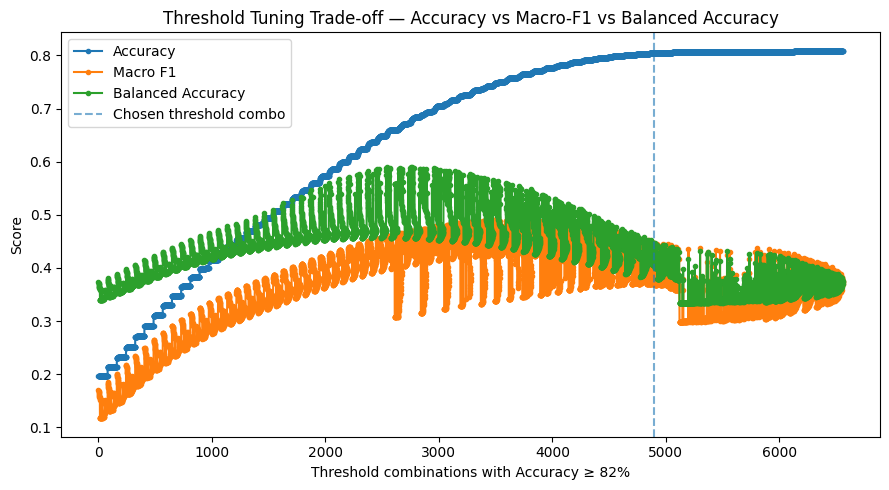


ISOTONIC PROBABILITY CALIBRATION — FIT ON OOF
Calibrated: band=[0.820,0.830], t_fatal=0.16, t_serious=0.41, OOF Macro-F1=0.4533
Calibration decision: USE (cal=0.4533, uncal=0.4469)

FINAL MODELS — FIT / EARLY-STOPPING SPLIT / UNTOUCHED TEST
XGBoost best iteration: 349
LightGBM best iteration: 350
CatBoost best iteration: 349

FINAL RESULT — UNTOUCHED TEST SET
              precision    recall  f1-score   support

       Fatal      0.212     0.223     0.217       669
     Serious      0.469     0.187     0.267      9140
      Slight      0.838     0.950     0.891     40715

    accuracy                          0.803     50524
   macro avg      0.506     0.453     0.458     50524
weighted avg      0.763     0.803     0.769     50524

Accuracy=0.8027  MacroF1=0.4585 BalancedAcc=0.4534  Kappa=0.2113

Overfitting check:
Held-out ES Accuracy=0.8046  Test Accuracy=0.8027  Gap=0.0020
Held-out ES MacroF1=0.4534  Test MacroF1=0.4585  Gap=-0.0051
The ES split is never used for model-weight fitt

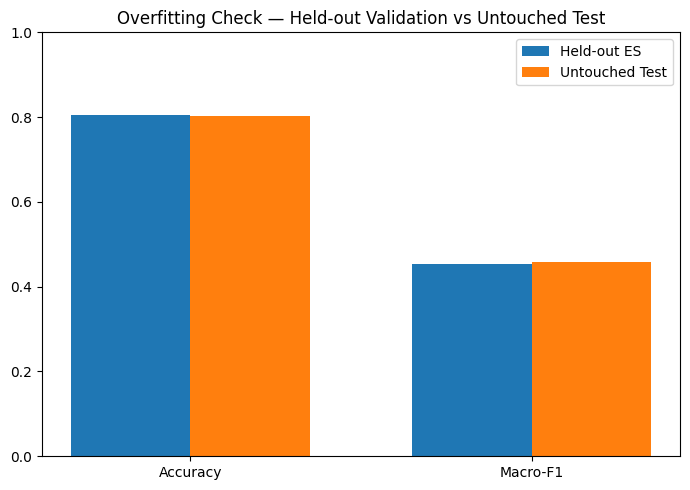


ABLATION STUDY
                                               accuracy  macro_f1  balanced_accuracy   kappa
0. Accident baseline\n(10 features, plain RF)    0.8059    0.2975             0.3333  0.0000
1. + Full Feature\nEngineering                   0.5307    0.3595             0.5567  0.1367
2. + SHAP Top-K\nSelection                       0.5350    0.3628             0.5617  0.1434
3. + 5-Fold CV\nEnsemble                         0.7655    0.4851             0.4768  0.2956
4. + Threshold Tuning\n+ Calibration             0.8027    0.4585             0.4534  0.2113
Saved /mnt/data/thesis_outputs_2017_2018/ablation_study_oof.png


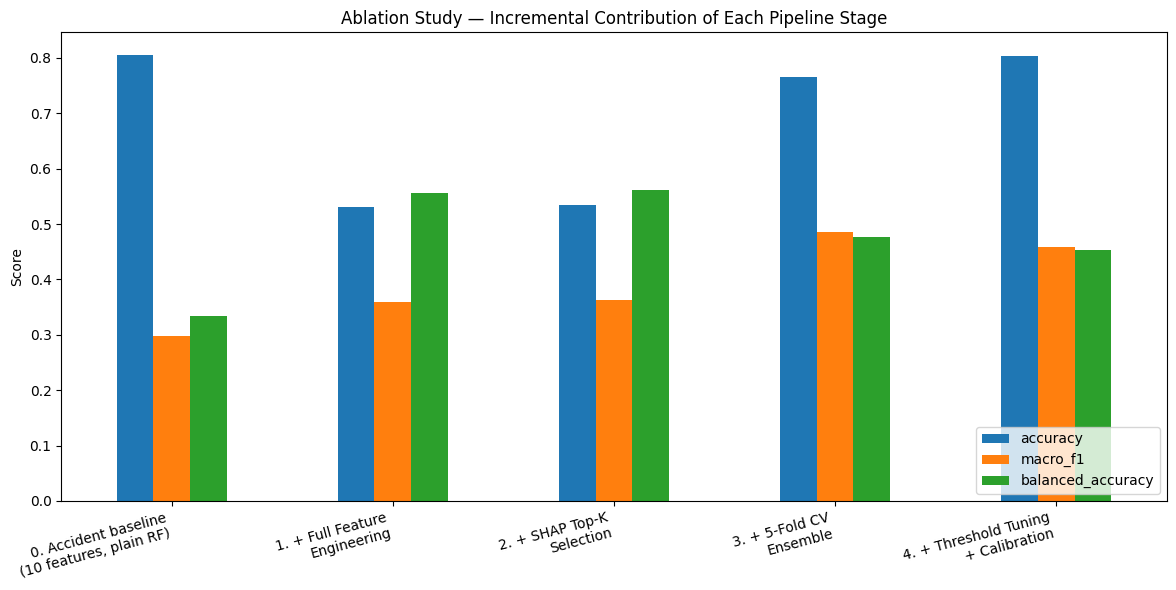


CONFORMAL PREDICTION — MARGINAL vs MONDRIAN

[Marginal] target=80%: coverage=0.801, avg set size=1.61
    True=Fatal: class-conditional coverage=0.789
    True=Serious: class-conditional coverage=0.708
    True=Slight: class-conditional coverage=0.822
[Mondrian] target=80%: coverage=0.801, avg set size=1.70
    True=Fatal: class-conditional coverage=0.807
    True=Serious: class-conditional coverage=0.803
    True=Slight: class-conditional coverage=0.801

[Marginal] target=90%: coverage=0.901, avg set size=2.06
    True=Fatal: class-conditional coverage=0.868
    True=Serious: class-conditional coverage=0.952
    True=Slight: class-conditional coverage=0.890
[Mondrian] target=90%: coverage=0.900, avg set size=2.04
    True=Fatal: class-conditional coverage=0.906
    True=Serious: class-conditional coverage=0.899
    True=Slight: class-conditional coverage=0.900
Saved /mnt/data/thesis_outputs_2017_2018/conformal_coverage_80.png


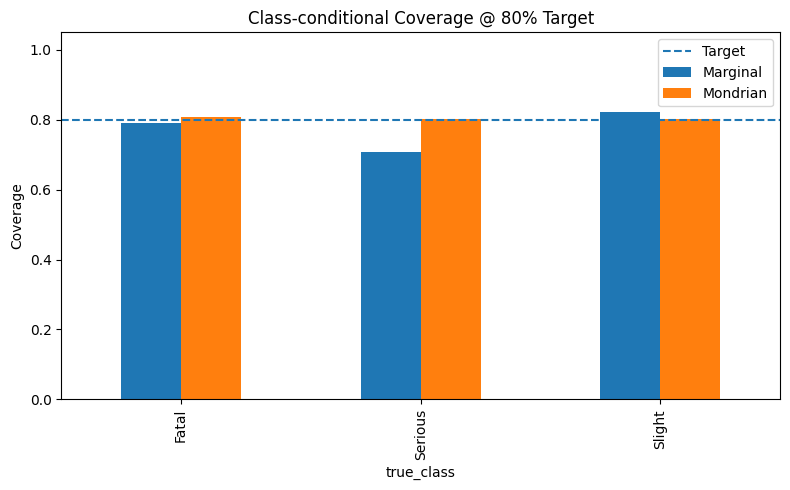

Saved /mnt/data/thesis_outputs_2017_2018/conformal_coverage_90.png


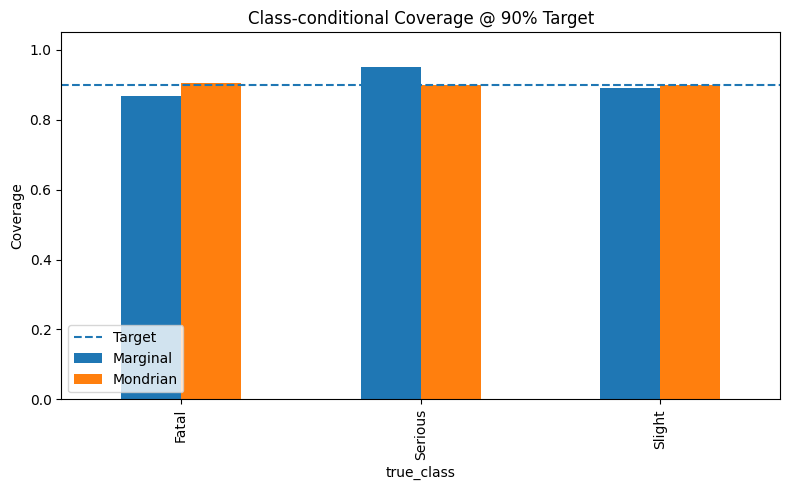


SELECTIVE PREDICTION — COVERAGE 100% -> 10%
Coverage=100% (n=50524) -> Accuracy=0.8106 MacroF1=0.4011 BalancedAcc=0.3892 Fatal retained=669/669
Coverage=90% (n=45475) -> Accuracy=0.8433 MacroF1=0.3772 BalancedAcc=0.3742 Fatal retained=341/669
Coverage=80% (n=40419) -> Accuracy=0.8689 MacroF1=0.3608 BalancedAcc=0.3624 Fatal retained=194/669
Coverage=70% (n=35373) -> Accuracy=0.8891 MacroF1=0.3616 BalancedAcc=0.3600 Fatal retained=126/669
Coverage=60% (n=30322) -> Accuracy=0.9079 MacroF1=0.3847 BalancedAcc=0.3723 Fatal retained=77/669
Coverage=50% (n=25318) -> Accuracy=0.9242 MacroF1=0.3856 BalancedAcc=0.3712 Fatal retained=44/669
Coverage=40% (n=20634) -> Accuracy=0.9402 MacroF1=0.3707 BalancedAcc=0.3590 Fatal retained=26/669
Coverage=30% (n=15172) -> Accuracy=0.9556 MacroF1=0.4091 BalancedAcc=0.3810 Fatal retained=14/669
Coverage=20% (n=10151) -> Accuracy=0.9696 MacroF1=0.4948 BalancedAcc=0.4444 Fatal retained=3/669
Coverage=10% (n=5096) -> Accuracy=0.9806 MacroF1=0.4951 BalancedAcc=0

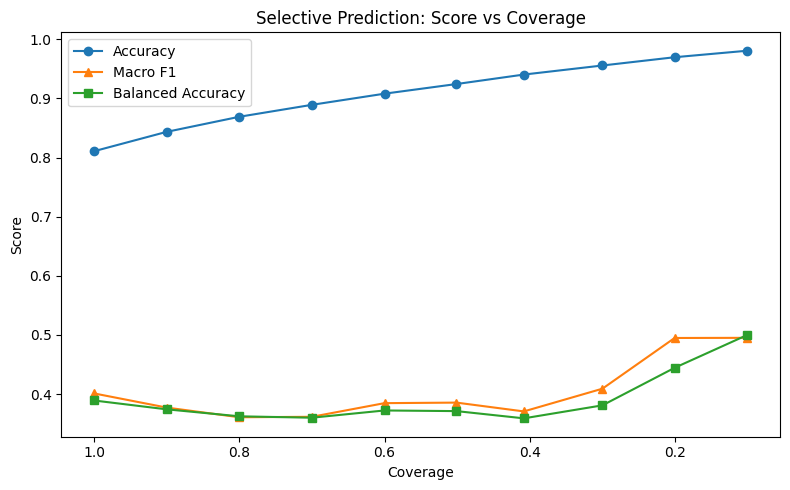


FAIRNESS AUDIT — DRIVER AGE / SEX
  SubgroupVariable Subgroup     N  Accuracy  MacroF1  FatalRecall  SeriousRecall Flagged
Age Band of Driver       -1  9830    0.8726   0.3966       0.0976         0.0762     Yes
Age Band of Driver       10  1020    0.7167   0.4430       0.1600         0.2852      No
Age Band of Driver       11   612    0.7010   0.4501       0.2353         0.2400      No
Age Band of Driver        2   163    0.7975   0.3151       0.0000         0.0312     Yes
Age Band of Driver        3   538    0.7955   0.3664       0.0000         0.1293     Yes
Age Band of Driver        4  5007    0.7843   0.4363       0.1475         0.1862      No
Age Band of Driver        5  7021    0.7976   0.4606       0.2222         0.1920      No
Age Band of Driver        6 11948    0.8103   0.4610       0.2317         0.1820      No
Age Band of Driver        7  7092    0.7858   0.4439       0.2178         0.1804      No
Age Band of Driver        8  5011    0.7577   0.4868       0.3048         0

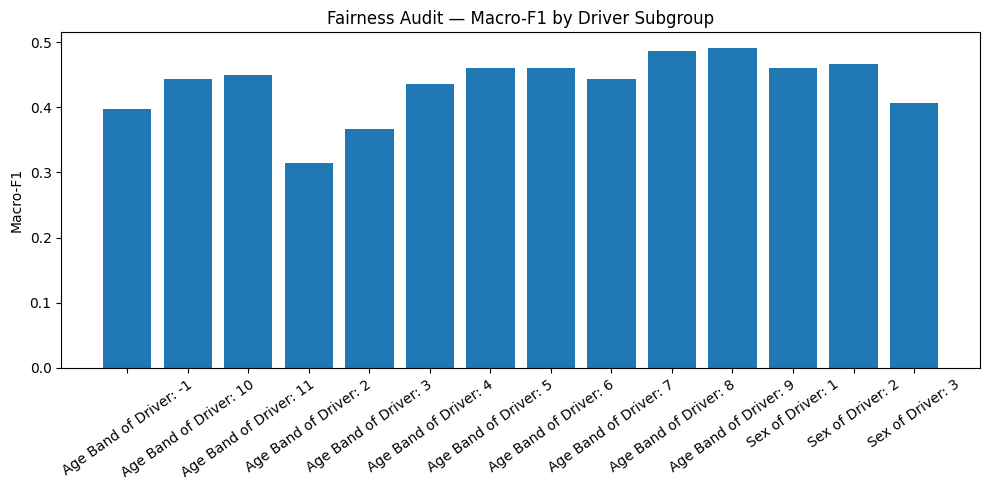


ROC/AUC, CALIBRATION, CONFUSION MATRIX, CLASS-WISE PERFORMANCE
Saved /mnt/data/thesis_outputs_2017_2018/roc_curves_oof.png


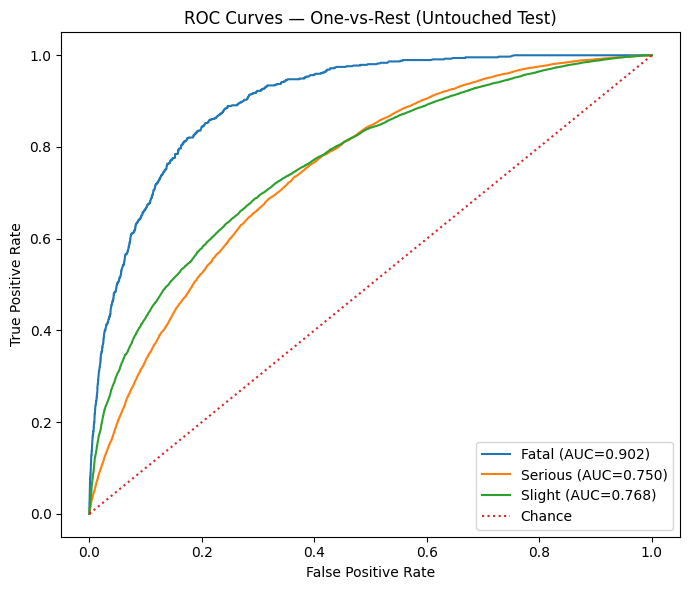

Per-class AUC: {'Fatal': 0.9017, 'Serious': 0.7498, 'Slight': 0.7677}
Saved /mnt/data/thesis_outputs_2017_2018/calibration_plot.png


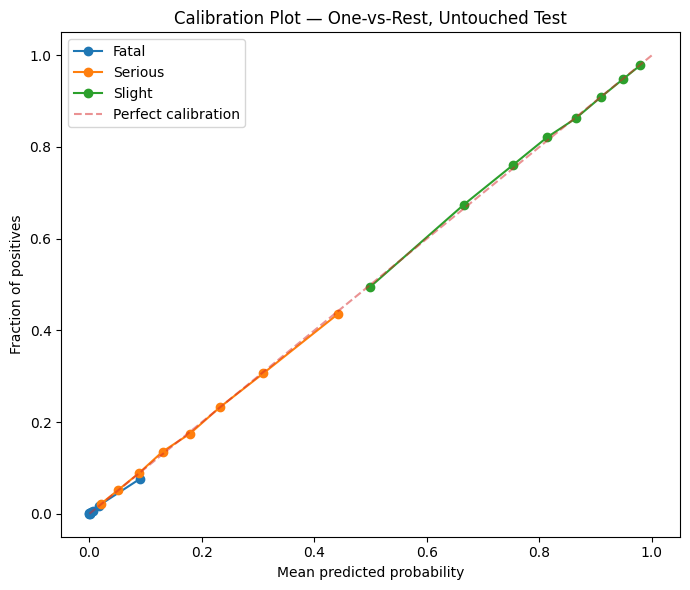

Saved /mnt/data/thesis_outputs_2017_2018/confusion_matrix_final.png


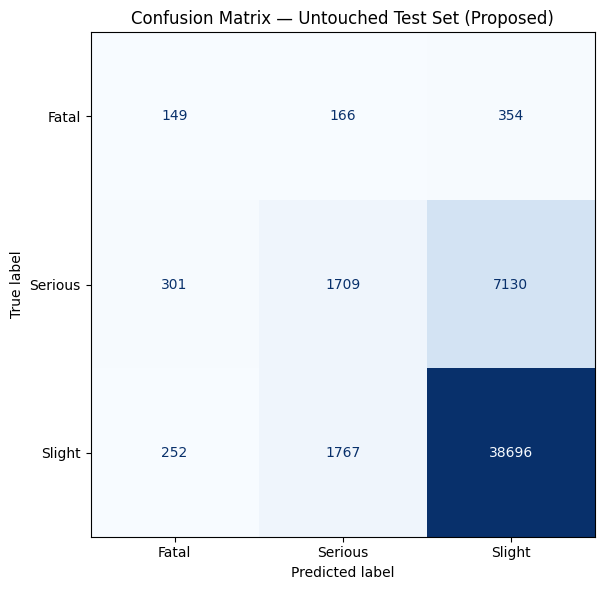

Saved /mnt/data/thesis_outputs_2017_2018/classwise_performance_final.png


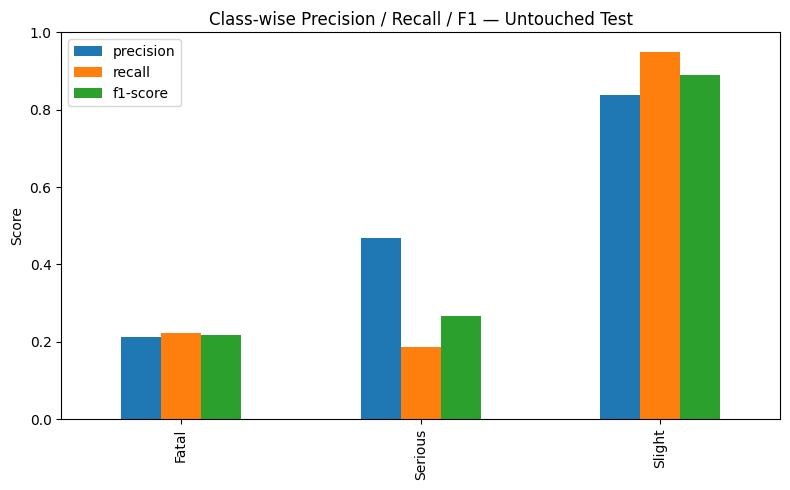


APPROACH 2 — INDEPENDENT ONE-vs-REST COMPARISON
Fatal-vs-rest OOF ROC-AUC: 0.8899
Serious-vs-rest OOF ROC-AUC: 0.7489
Slight-vs-rest OOF ROC-AUC: 0.7649
Fatal: threshold=0.84, OOF binary F1=0.2069
Serious: threshold=0.56, OOF binary F1=0.4376
Slight: threshold=0.20, OOF binary F1=0.8961
Approach 2 TEST: Accuracy=0.7936 MacroF1=0.4214 BalancedAcc=0.4146 Kappa=0.2640
                                         Approach  Accuracy  MacroF1  BalancedAccuracy  Kappa
1. Margin-based + threshold + calibration (FINAL)    0.8027   0.4585            0.4534 0.2113
                       2. Independent One-vs-Rest    0.7936   0.4214            0.4146 0.2640
Saved /mnt/data/thesis_outputs_2017_2018/approach_comparison.png


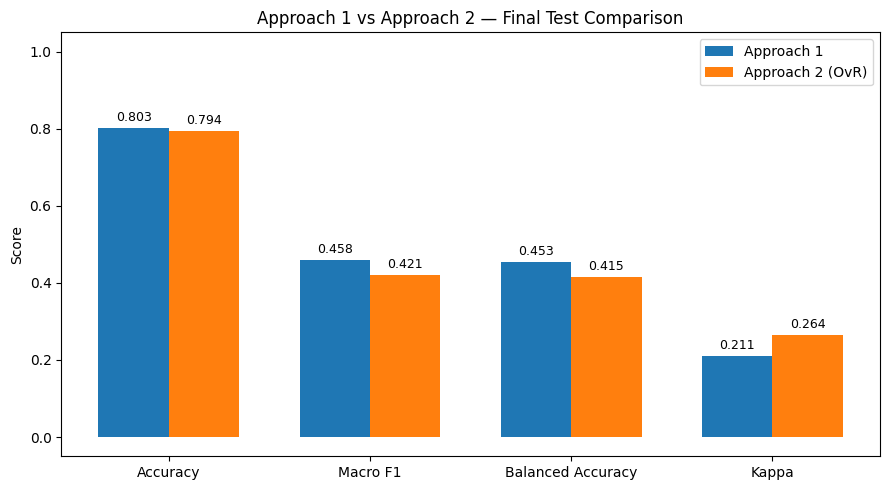


THESIS TABLES

FINAL RESULT SUMMARY
           Metric  Final result
         Accuracy        0.8027
  Macro Precision        0.5065
     Macro Recall        0.4534
         Macro F1        0.4585
      Weighted F1        0.7690
Balanced Accuracy        0.4534
            Kappa        0.2113
     Fatal Recall        0.2227
   Serious Recall        0.1870
    Slight Recall        0.9504

BASELINE COMPARISON
                 Model  Accuracy  MacroF1  BalancedAccuracy  Kappa  FatalF1  FatalRecall  SeriousRecall
   Logistic Regression    0.5602   0.3705            0.5584 0.1398   0.0948       0.6951         0.3823
         Random Forest    0.5387   0.3653            0.5645 0.1449   0.0851       0.7235         0.4039
    LightGBM (untuned)    0.7645   0.4871            0.4813 0.2949   0.1838       0.1420         0.4585
         Tuned XGBoost    0.7651   0.4861            0.4786 0.2963   0.1785       0.1300         0.4623
        Tuned LightGBM    0.7636   0.4856            0.4786 0.2920   0

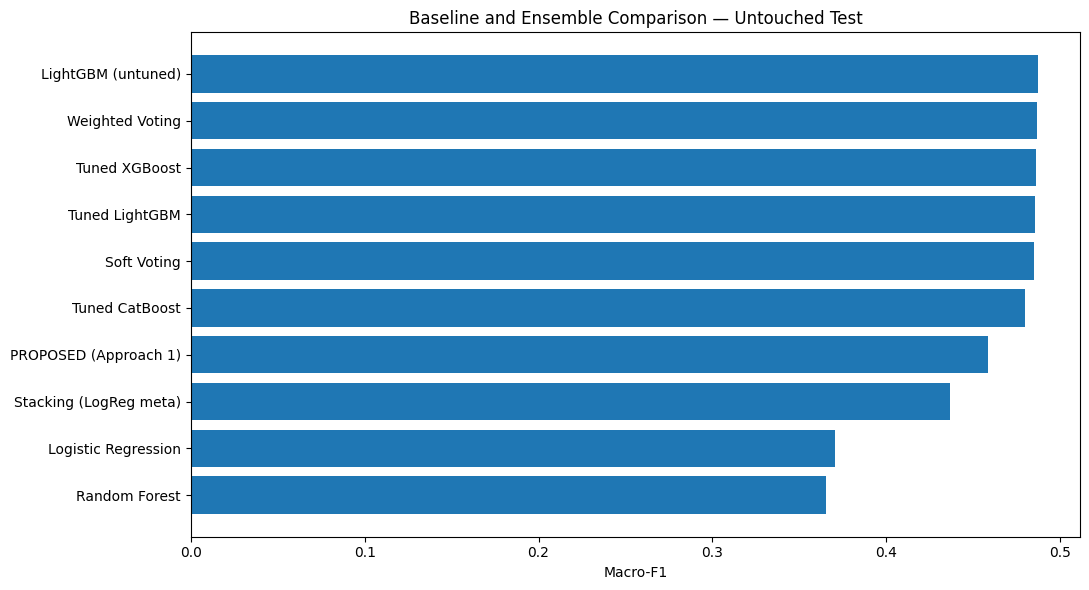


BEFORE vs AFTER THRESHOLD OPTIMIZATION
                                                 Accuracy  Macro Precision  Macro Recall  Macro F1  Weighted F1  Fatal Recall
Argmax                                             0.7655           0.5184        0.4768    0.4851       0.7703        0.1256
Threshold optimized (+ calibration if selected)    0.8027           0.5065        0.4534    0.4585       0.7690        0.2227
Saved /mnt/data/thesis_outputs_2017_2018/before_after_threshold.png


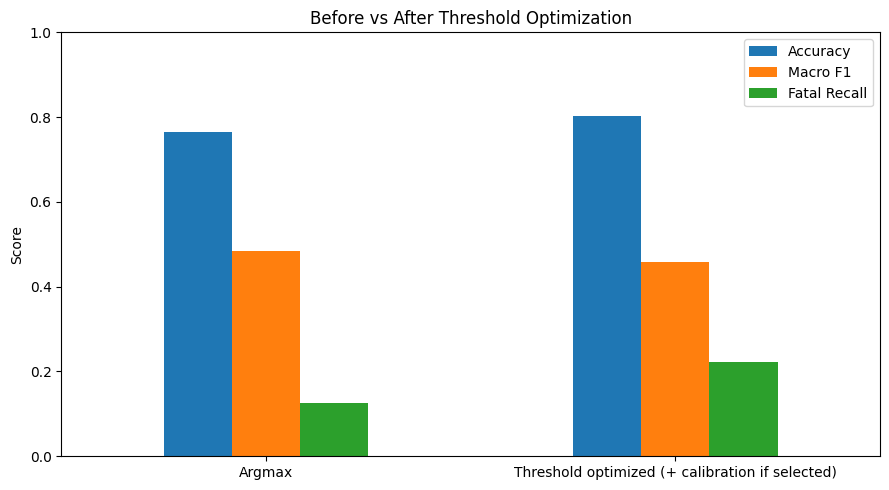


GENERALIZATION — TRAIN / CALIBRATION(ES) / TEST
         Stage  Accuracy  MacroF1  BalancedAccuracy  FatalRecall  SeriousRecall
      Training    0.8146   0.5280            0.5208       0.3844         0.2237
Calibration/ES    0.8046   0.4534            0.4465       0.1940         0.1935
Untouched Test    0.8027   0.4585            0.4534       0.2227         0.1870
Training -> Test Macro-F1 gap = 0.0695
Calibration/ES -> Test Macro-F1 gap = -0.0051
Saved /mnt/data/thesis_outputs_2017_2018/generalization_train_calibration_test.png


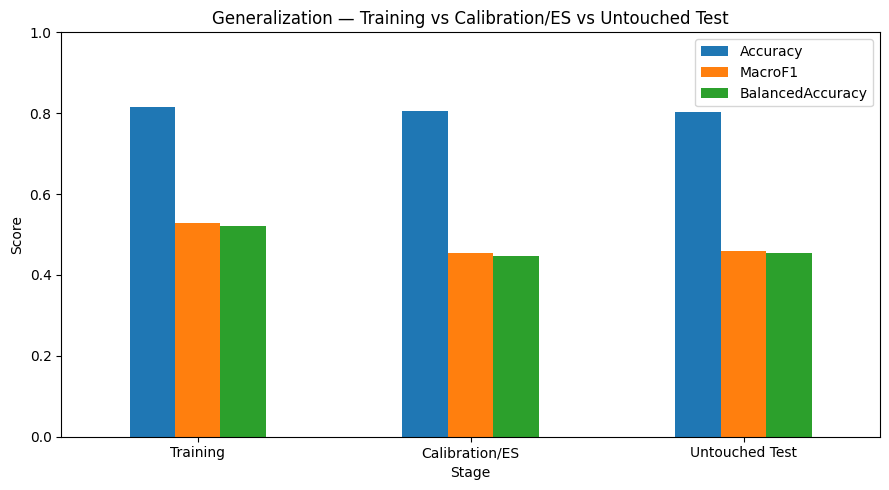


HYPERPARAMETER SEARCH SUMMARY
LightGBM: best ES Macro-F1=0.4731 at lr=0.05, depth=6
XGBoost: best ES Macro-F1=0.4719 at lr=0.05, depth=6
CatBoost: best ES Macro-F1=0.4539 at lr=0.05, depth=6
   Model  LearningRate  Depth                                MainParameters  Objective_MacroF1
LightGBM          0.03      5                       leaves=18, min_child=40             0.4585
LightGBM          0.04      6                       leaves=20, min_child=40             0.4665
LightGBM          0.05      6                       leaves=20, min_child=40             0.4731
LightGBM          0.04      7                       leaves=22, min_child=40             0.4687
 XGBoost          0.03      5 min_child_weight=8, reg_alpha=1, reg_lambda=3             0.4489
 XGBoost          0.04      6 min_child_weight=8, reg_alpha=1, reg_lambda=3             0.4648
 XGBoost          0.05      6 min_child_weight=8, reg_alpha=1, reg_lambda=3             0.4719
 XGBoost          0.04      7 min_child_weight=8

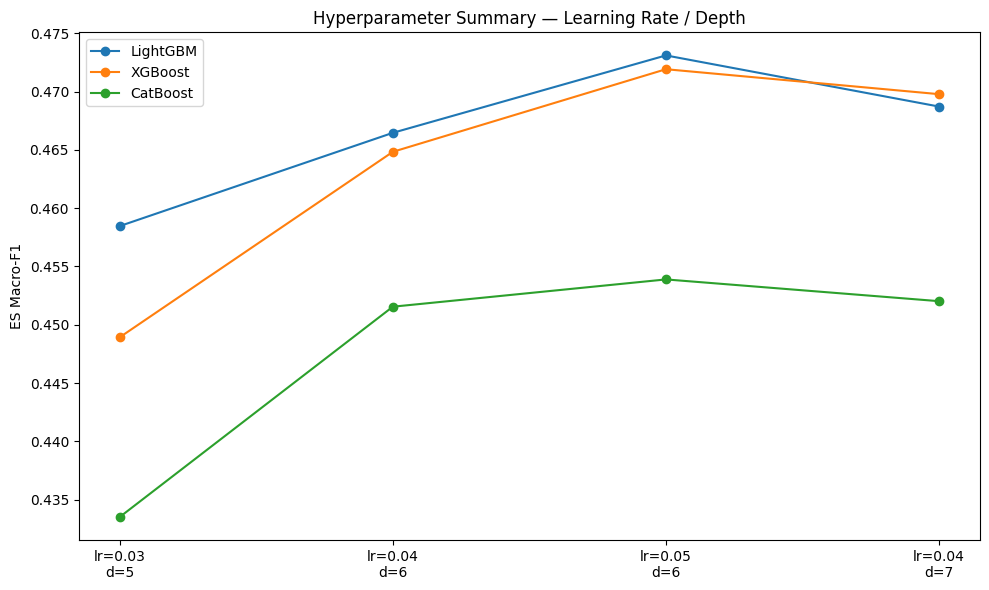


ENSEMBLE STRATEGY COMPARISON — CALIBRATION/ES SET
                                   Strategy  CalibrationMacroF1
                                Soft Voting              0.4759
                            Weighted Voting              0.4764
Stacking (Logistic Regression meta-learner)              0.4316
Saved /mnt/data/thesis_outputs_2017_2018/ensemble_strategy_comparison.png


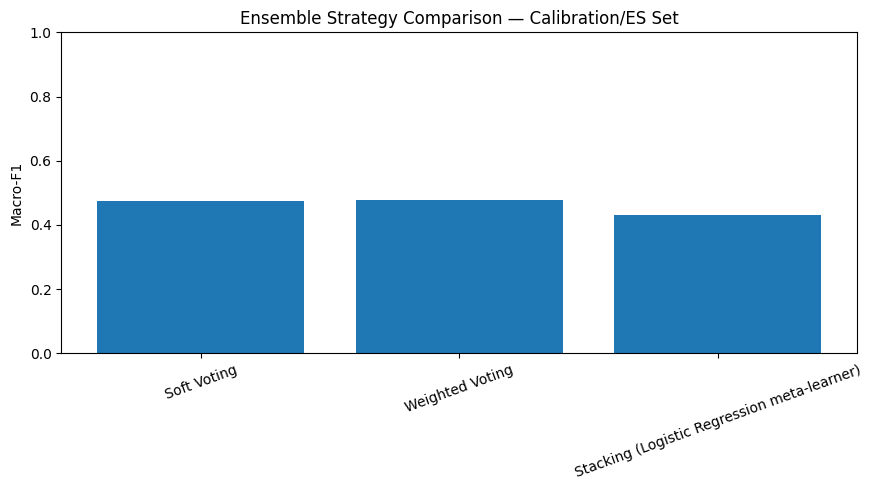


FINAL PER-CLASS PERFORMANCE
       Class  Precision  Recall     F1  Support
       Fatal     0.2123  0.2227 0.2174      669
     Serious     0.4692  0.1870 0.2674     9140
      Slight     0.8379  0.9504 0.8906    40715
   Macro Avg     0.5065  0.4534 0.4585    50524
Weighted Avg     0.7630  0.8027 0.7690    50524

SUBGROUP FAIRNESS AUDIT
  SubgroupVariable Subgroup     N  Accuracy  MacroF1  FatalRecall  SeriousRecall Flagged
Age Band of Driver       -1  9830    0.8726   0.3966       0.0976         0.0762     Yes
Age Band of Driver       10  1020    0.7167   0.4430       0.1600         0.2852      No
Age Band of Driver       11   612    0.7010   0.4501       0.2353         0.2400      No
Age Band of Driver        2   163    0.7975   0.3151       0.0000         0.0312     Yes
Age Band of Driver        3   538    0.7955   0.3664       0.0000         0.1293     Yes
Age Band of Driver        4  5007    0.7843   0.4363       0.1475         0.1862      No
Age Band of Driver        5  7021  

In [ ]:
# -*- coding: utf-8 -*-
"""Untitled6.ipynb

Automatically generated by Colab.

Original file is located at
    https://colab.research.google.com/drive/1YzjU3KJsL3v9-0D_GHoj-iMSu6dHeCLr
"""

import os
import json
import zipfile
import warnings
import importlib
import subprocess
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")


def ensure_package(pip_name, import_name=None):
    import_name = import_name or pip_name
    try:
        return importlib.import_module(import_name)
    except ImportError:
        print(f"Installing missing package: {pip_name} ...")
        subprocess.run([sys.executable, "-m", "pip", "install", "-q", pip_name], check=True)
        return importlib.import_module(import_name)


# ------------------------------------------------------------
# Packages
# ------------------------------------------------------------
ensure_package("xgboost")
ensure_package("lightgbm")
ensure_package("catboost")
try:
    ensure_package("shap")
except Exception:
    pass

from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import LabelEncoder, label_binarize, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.isotonic import IsotonicRegression
from sklearn.calibration import calibration_curve
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    recall_score,
    classification_report,
    confusion_matrix,
    cohen_kappa_score,
    balanced_accuracy_score,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score,
)
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
import lightgbm as lgb
from catboost import CatBoostClassifier


# ============================================================
# 0. GLOBAL SETTINGS
# ============================================================
RNG = 42
np.random.seed(RNG)

MAX_DEPTH = 6
MIN_LEAF = 8
N_FOLDS = 5
TOP_K_FEATURES = 30

# Target accuracy band requested for the thesis pipeline.
ACC_CONSTRAINT = 0.82
ACC_BAND = (0.82, 0.83)

# Mild minority weighting: do not destroy majority-class accuracy.
WEIGHT_POWER = 0.65
MAX_CLASS_WEIGHT = 3.5

# Ensemble weights used only where the original pipeline explicitly
# compared weighted voting; the main proposed result remains equal-soft voting
# + threshold optimization + optional calibration.
XGB_WEIGHT = 0.45
LGBM_WEIGHT = 0.30
CAT_WEIGHT = 0.25

CLASS_NAMES = ["Fatal", "Serious", "Slight"]
CLASS_IDS = [0, 1, 2]

OUTDIR = Path("/mnt/data/thesis_outputs_2017_2018")
OUTDIR.mkdir(parents=True, exist_ok=True)


def savefig(name):
    path = OUTDIR / name
    plt.savefig(path, dpi=180, bbox_inches="tight")
    print(f"Saved {path}")


def safe_div(a, b):
    return a / b.replace(0, np.nan).fillna(1)


def native(obj):
    if isinstance(obj, dict):
        return {str(k): native(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple)):
        return [native(v) for v in obj]
    if isinstance(obj, np.generic):
        return obj.item()
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    return obj


# ============================================================
# 1. DATA LOADING — 2017 + 2018
# ============================================================
print("\n" + "=" * 72)
print("LOADING UK ROAD SAFETY DATA — 2017 + 2018")
print("=" * 72)


def locate_dataset():
    """
    Locate the UK Road Safety 2017/2018 files in common notebook/upload
    locations. This works in Jupyter, Colab and normal Python execution.
    """
    search_roots = [
        Path("/mnt/data/ds1718"),
        Path("/mnt/data"),
        Path("/content"),
        Path.cwd(),
    ]

    # Prefer the exact ZIP if it exists.
    zip_names = ["dataset17,18.zip", "dataset17_18.zip", "dataset17-18.zip"]

    for root in search_roots:
        if not root.exists():
            continue
        for name in zip_names:
            direct = root / name
            if direct.exists():
                return direct

        # Recursive fallback for mounted/uploaded ZIPs.
        for name in zip_names:
            matches = list(root.rglob(name))
            if matches:
                return matches[0]

    return None


def _find_required_csvs(search_roots, required):
    """
    Recursively locate each required CSV. Returns a filename -> Path dict.
    """
    found = {}

    for root in search_roots:
        if not root.exists():
            continue

        for filename in required:
            if filename in found:
                continue

            matches = list(root.rglob(filename))
            if matches:
                found[filename] = matches[0]

    return found


def load_year_tables():
    print("\n" + "=" * 72)
    print("LOADING UK ROAD SAFETY DATA — 2017 + 2018")
    print("=" * 72)

    required = [
        "Accidents_2017.csv",
        "Accidents_2018.csv",
        "Vehicles_2017.csv",
        "Vehicles_2018.csv",
        "Casualties_2017.csv",
        "Casualties_2018.csv",
    ]

    # Actual uploaded-file locations used by the current notebook/session.
    search_roots = [
        Path("/mnt/data/ds1718"),
        Path("/mnt/data"),
        Path("/content"),
        Path.cwd(),
    ]

    # --------------------------------------------------------------
    # 1) First try to find the six CSV files directly.
    # --------------------------------------------------------------
    found = _find_required_csvs(search_roots, required)

    # --------------------------------------------------------------
    # 2) If necessary, find and extract the ZIP.
    # --------------------------------------------------------------
    if len(found) < len(required):
        zip_path = locate_dataset()

        if zip_path is not None:
            extract_dir = Path("/mnt/data/dataset17_18_extracted")
            extract_dir.mkdir(parents=True, exist_ok=True)

            print("ZIP found:", zip_path)
            print("Extracting dataset...")

            with zipfile.ZipFile(zip_path, "r") as zf:
                zf.extractall(extract_dir)

            extracted_found = _find_required_csvs(
                [extract_dir], required
            )
            found.update(extracted_found)

    # --------------------------------------------------------------
    # 3) Validate all six files.
    # --------------------------------------------------------------
    missing = [f for f in required if f not in found]

    if missing:
        # ----------------------------------------------------------
        # 3b) Interactive upload fallback for Jupyter/Colab.
        # This is the important fallback when the notebook kernel
        # cannot see the files mounted in /mnt/data.
        # ----------------------------------------------------------
        uploaded_ok = False

        try:
            from google.colab import files as colab_files

            print("\nDataset files are not visible to this notebook kernel.")
            print("Opening the Colab upload dialog...")
            uploaded = colab_files.upload()

            # Uploaded objects are written into the current working directory.
            upload_root = Path.cwd()

            # Also handle a single ZIP upload.
            for name in uploaded.keys():
                candidate = upload_root / name

                if candidate.suffix.lower() == ".zip":
                    extract_dir = Path.cwd() / "dataset17_18_extracted"
                    extract_dir.mkdir(parents=True, exist_ok=True)

                    with zipfile.ZipFile(candidate, "r") as zf:
                        zf.extractall(extract_dir)

                    extracted = _find_required_csvs(
                        [extract_dir], required
                    )
                    found.update(extracted)

                elif candidate.name in required:
                    found[candidate.name] = candidate

            missing = [f for f in required if f not in found]
            uploaded_ok = len(missing) == 0

        except Exception as upload_error:
            print("Automatic Colab upload was not available:", upload_error)

        if uploaded_ok:
            print("\nUpload successful. Files found:")
            for filename in required:
                print(f"  {filename} -> {found[filename]}")
        else:
            print("\nLocated files:")
        if found:
            for filename, path in found.items():
                print(f"  {filename} -> {path}")
        else:
            print("  None")

        missing = [f for f in required if f not in found]

        if missing:
            print("\nMissing files:")
            for filename in missing:
                print(f"  {filename}")

        if missing:
            raise FileNotFoundError(
                "Could not locate the required UK Road Safety 2017/2018 CSV files. "
                "The loader searched /mnt/data/ds1718, /mnt/data, /content and "
                "the current working directory."
            )

    print("\nDataset files found successfully:")
    for filename in required:
        print(f"  {filename} -> {found[filename]}")

    # --------------------------------------------------------------
    # 4) Read each table.
    # low_memory=False avoids mixed-type inference problems in UK data.
    # --------------------------------------------------------------
    accidents_2017 = pd.read_csv(
        found["Accidents_2017.csv"], low_memory=False
    )
    accidents_2018 = pd.read_csv(
        found["Accidents_2018.csv"], low_memory=False
    )
    vehicles_2017 = pd.read_csv(
        found["Vehicles_2017.csv"], low_memory=False
    )
    vehicles_2018 = pd.read_csv(
        found["Vehicles_2018.csv"], low_memory=False
    )
    casualties_2017 = pd.read_csv(
        found["Casualties_2017.csv"], low_memory=False
    )
    casualties_2018 = pd.read_csv(
        found["Casualties_2018.csv"], low_memory=False
    )

    # --------------------------------------------------------------
    # 5) Combine 2017 + 2018.
    # --------------------------------------------------------------
    accidents = pd.concat(
        [accidents_2017, accidents_2018],
        ignore_index=True
    )
    vehicles = pd.concat(
        [vehicles_2017, vehicles_2018],
        ignore_index=True
    )
    casualties = pd.concat(
        [casualties_2017, casualties_2018],
        ignore_index=True
    )

    print("\nLoaded successfully:")
    print(f"  Accidents : {accidents.shape}")
    print(f"  Vehicles  : {vehicles.shape}")
    print(f"  Casualties: {casualties.shape}")

    return accidents, vehicles, casualties


accidents, vehicles, casualties = load_year_tables()

print("Accidents:", accidents.shape)
print("Vehicles:", vehicles.shape)
print("Casualties:", casualties.shape)

TARGET_RAW = "Accident_Severity"
if TARGET_RAW not in accidents.columns:
    raise KeyError(f"Target column {TARGET_RAW!r} not found.")

print("Raw severity distribution:")
print(accidents[TARGET_RAW].value_counts(dropna=False).sort_index())


# ============================================================
# 2. ACCIDENT-LEVEL INTEGRATION + FEATURE ENGINEERING
# ============================================================
# The target exists at accident level. Vehicle and casualty files contain
# multiple rows per accident, so they are aggregated to ONE ROW PER ACCIDENT.
# Direct outcome/leakage variables such as Casualty_Severity are intentionally
# NOT used as predictors.
# ============================================================
print("\n" + "=" * 72)
print("ACCIDENT-LEVEL INTEGRATION + FEATURE ENGINEERING")
print("=" * 72)

acc = accidents.copy()
veh = vehicles.copy()
cas = casualties.copy()
# Normalize join keys across CSVs; some releases contain mixed integer/string IDs.
for _d in (acc, veh, cas):
    _d["Accident_Index"] = _d["Accident_Index"].astype(str).str.strip()

# Preserve target before feature construction.
# OFFICIAL UK STATS19 coding: 1 = Fatal, 2 = Serious, 3 = Slight.
# Internal model labels: 0 = Fatal, 1 = Serious, 2 = Slight.
acc[TARGET_RAW] = pd.to_numeric(acc[TARGET_RAW], errors="coerce")
acc = acc[acc[TARGET_RAW].isin([1, 2, 3])].copy()
acc["Accident_severity_target"] = acc[TARGET_RAW].map({1: 0, 2: 1, 3: 2}).astype(int)

# Basic accident fields.
base_cols = [
    "Accident_Index",
    "Location_Easting_OSGR",
    "Location_Northing_OSGR",
    "Longitude",
    "Latitude",
    "Police_Force",
    TARGET_RAW,
    "Number_of_Vehicles",
    "Number_of_Casualties",
    "Date",
    "Day_of_Week",
    "Time",
    "Local_Authority_(District)",
    "Local_Authority_(Highway)",
    "1st_Road_Class",
    "1st_Road_Number",
    "Road_Type",
    "Speed_limit",
    "Junction_Detail",
    "Junction_Control",
    "2nd_Road_Class",
    "2nd_Road_Number",
    "Pedestrian_Crossing-Human_Control",
    "Pedestrian_Crossing-Physical_Facilities",
    "Light_Conditions",
    "Weather_Conditions",
    "Road_Surface_Conditions",
    "Special_Conditions_at_Site",
    "Carriageway_Hazards",
    "Urban_or_Rural_Area",
    "Did_Police_Officer_Attend_Scene_of_Accident",
    "LSOA_of_Accident_Location",
    "Accident_severity_target",
]
base_cols = [c for c in base_cols if c in acc.columns]
acc_base = acc[base_cols].copy()

# Date/time engineering.
acc_base["Date_parsed"] = pd.to_datetime(acc_base["Date"], dayfirst=True, errors="coerce")
acc_base["year"] = acc_base["Date_parsed"].dt.year
acc_base["month"] = acc_base["Date_parsed"].dt.month
acc_base["day_of_month"] = acc_base["Date_parsed"].dt.day
acc_base["day_of_year"] = acc_base["Date_parsed"].dt.dayofyear
acc_base["quarter"] = acc_base["Date_parsed"].dt.quarter
acc_base["week_of_year"] = acc_base["Date_parsed"].dt.isocalendar().week.astype(float)

# Time can be malformed in a small number of rows; coerce safely.
time_parsed = pd.to_datetime(acc_base["Time"].astype(str).str.strip(), format="%H:%M:%S", errors="coerce")
if time_parsed.isna().mean() > 0.25:
    time_parsed = pd.to_datetime(acc_base["Time"].astype(str).str.strip(), format="%H:%M", errors="coerce")
acc_base["hour"] = time_parsed.dt.hour
acc_base["minute"] = time_parsed.dt.minute
acc_base["hour"] = acc_base["hour"].fillna(acc_base["hour"].median())
acc_base["minute"] = acc_base["minute"].fillna(0)
acc_base["hour_sin"] = np.sin(2 * np.pi * acc_base["hour"] / 24.0)
acc_base["hour_cos"] = np.cos(2 * np.pi * acc_base["hour"] / 24.0)
acc_base["is_night"] = ((acc_base["hour"] >= 19) | (acc_base["hour"] <= 5)).astype(int)
acc_base["is_weekend"] = acc_base["Day_of_Week"].isin([1, 7]).astype(int)

# Avoid retaining raw Date/Time in the model.
acc_base = acc_base.drop(columns=[c for c in ["Date", "Date_parsed", "Time"] if c in acc_base.columns])

# ------------------------------------------------------------
# Vehicle aggregation
# ------------------------------------------------------------
veh_num_candidates = [
    "Age_of_Driver", "Engine_Capacity_(CC)", "Age_of_Vehicle",
    "Driver_IMD_Decile", "Vehicle_IMD_Decile",
]
veh_cat_candidates = [
    "Vehicle_Type", "Towing_and_Articulation", "Vehicle_Manoeuvre",
    "Vehicle_Location-Restricted_Lane", "Junction_Location",
    "Skidding_and_Overturning", "Hit_Object_in_Carriageway",
    "Vehicle_Leaving_Carriageway", "Hit_Object_off_Carriageway",
    "1st_Point_of_Impact", "Was_Vehicle_Left_Hand_Drive?",
    "Journey_Purpose_of_Driver", "Sex_of_Driver", "Age_Band_of_Driver",
    "Propulsion_Code", "Driver_Home_Area_Type",
]
veh_num_candidates = [c for c in veh_num_candidates if c in veh.columns]
veh_cat_candidates = [c for c in veh_cat_candidates if c in veh.columns]

veh_work = veh.copy()
for c in veh_num_candidates:
    veh_work[c] = pd.to_numeric(veh_work[c], errors="coerce")

veh_agg = veh_work.groupby("Accident_Index", sort=False).size().rename("vehicle_rows").to_frame()
for c in veh_num_candidates:
    g = veh_work.groupby("Accident_Index")[c]
    veh_agg[f"veh_{c}_mean"] = g.mean()
    veh_agg[f"veh_{c}_max"] = g.max()
    veh_agg[f"veh_{c}_min"] = g.min()
    veh_agg[f"veh_{c}_std"] = g.std().fillna(0)

# Fast categorical aggregation: first observed category + diversity.
# For the two audit-critical driver variables, use the true mode.
for c in veh_cat_candidates:
    g = veh_work.groupby("Accident_Index")[c]
    if c in ["Age_Band_of_Driver", "Sex_of_Driver", "Vehicle_Type"]:
        mode_s = g.agg(lambda s: s.dropna().mode().iloc[0] if len(s.dropna().mode()) else "Unknown")
    else:
        mode_s = g.first().fillna("Unknown")
    nunique_s = g.nunique(dropna=True)
    veh_agg[f"veh_{c}_mode"] = mode_s.astype(str)
    veh_agg[f"veh_{c}_nunique"] = nunique_s

# Driver sex proportion for fairness/context and model input.
if "Sex_of_Driver" in veh_work.columns:
    sex_num = pd.to_numeric(veh_work["Sex_of_Driver"], errors="coerce")
    veh_work["_male_driver"] = (sex_num == 1).astype(float)
    veh_agg["veh_male_driver_ratio"] = veh_work.groupby("Accident_Index")["_male_driver"].mean()

# ------------------------------------------------------------
# Casualty aggregation
# ------------------------------------------------------------
# IMPORTANT: Casualty_Severity is excluded because it is directly tied to the
# injury outcome and would create target leakage / post-event information.
cas_num_candidates = [
    "Age_of_Casualty", "Casualty_IMD_Decile",
]
cas_cat_candidates = [
    "Casualty_Class", "Sex_of_Casualty", "Age_Band_of_Casualty",
    "Pedestrian_Location", "Pedestrian_Movement", "Car_Passenger",
    "Bus_or_Coach_Passenger", "Pedestrian_Road_Maintenance_Worker",
    "Casualty_Type", "Casualty_Home_Area_Type",
]
cas_num_candidates = [c for c in cas_num_candidates if c in cas.columns]
cas_cat_candidates = [c for c in cas_cat_candidates if c in cas.columns]

cas_work = cas.copy()
for c in cas_num_candidates:
    cas_work[c] = pd.to_numeric(cas_work[c], errors="coerce")

cas_agg = cas_work.groupby("Accident_Index", sort=False).size().rename("casualty_rows").to_frame()
for c in cas_num_candidates:
    g = cas_work.groupby("Accident_Index")[c]
    cas_agg[f"cas_{c}_mean"] = g.mean()
    cas_agg[f"cas_{c}_max"] = g.max()
    cas_agg[f"cas_{c}_min"] = g.min()
    cas_agg[f"cas_{c}_std"] = g.std().fillna(0)

for c in cas_cat_candidates:
    g = cas_work.groupby("Accident_Index")[c]
    mode_s = g.first().fillna("Unknown")
    nunique_s = g.nunique(dropna=True)
    cas_agg[f"cas_{c}_mode"] = mode_s.astype(str)
    cas_agg[f"cas_{c}_nunique"] = nunique_s

# Merge everything at accident level.
df = acc_base.merge(veh_agg, left_on="Accident_Index", right_index=True, how="left")
df = df.merge(cas_agg, left_on="Accident_Index", right_index=True, how="left")

# Target and identifier handling.
y = df["Accident_severity_target"].astype(int).values

# Sanity check: class order MUST be Fatal, Serious, Slight.
_expected_counts = np.array([(acc[TARGET_RAW] == 1).sum(), (acc[TARGET_RAW] == 2).sum(), (acc[TARGET_RAW] == 3).sum()])
_actual_counts = np.bincount(y, minlength=3)
if not np.array_equal(_expected_counts, _actual_counts):
    raise RuntimeError(f"Severity mapping error: expected Fatal/Serious/Slight={_expected_counts.tolist()}, got={_actual_counts.tolist()}")
print("Verified target mapping: 0=Fatal, 1=Serious, 2=Slight")

# Original-style engineered features.
df["casualty_per_vehicle"] = safe_div(
    pd.to_numeric(df["Number_of_Casualties"], errors="coerce"),
    pd.to_numeric(df["Number_of_Vehicles"], errors="coerce"),
)
df["multi_vehicle"] = (pd.to_numeric(df["Number_of_Vehicles"], errors="coerce") > 1).astype(int)
df["mass_casualty"] = (pd.to_numeric(df["Number_of_Casualties"], errors="coerce") >= 3).astype(int)
df["speed_x_vehicle"] = pd.to_numeric(df["Speed_limit"], errors="coerce") * pd.to_numeric(df["Number_of_Vehicles"], errors="coerce")
df["casualty_x_speed"] = pd.to_numeric(df["Number_of_Casualties"], errors="coerce") * pd.to_numeric(df["Speed_limit"], errors="coerce")
df["rural_x_speed"] = pd.to_numeric(df["Urban_or_Rural_Area"], errors="coerce") * pd.to_numeric(df["Speed_limit"], errors="coerce")

# Interaction features use string-safe concatenation.
def concat_feature(a, b):
    return df[a].astype(str).fillna("Unknown") + "_" + df[b].astype(str).fillna("Unknown")

for a, b, name in [
    ("Light_Conditions", "Weather_Conditions", "light_x_weather"),
    ("Road_Surface_Conditions", "Weather_Conditions", "surface_x_weather"),
    ("Junction_Detail", "Road_Type", "junction_x_road"),
    ("Junction_Control", "Road_Type", "control_x_road"),
    ("Urban_or_Rural_Area", "Road_Type", "urban_x_road"),
    ("1st_Road_Class", "Speed_limit", "roadclass_x_speed"),
]:
    if a in df.columns and b in df.columns:
        df[name] = concat_feature(a, b)

# Drop direct identifiers and the raw target columns from predictors.
DROP_ID_TARGET = ["Accident_Index", TARGET_RAW, "Accident_severity_target"]
feature_cols = [c for c in df.columns if c not in DROP_ID_TARGET]

# Keep an explicit copy of raw grouping variables for later fairness audit.
# Vehicle aggregation gives one driver-group representation per accident.
if "veh_Age_Band_of_Driver_mode" in df.columns:
    AGE_RAW = df["veh_Age_Band_of_Driver_mode"].astype(str).fillna("Unknown").copy()
else:
    AGE_RAW = pd.Series("Unknown", index=df.index)
if "veh_Sex_of_Driver_mode" in df.columns:
    SEX_RAW = df["veh_Sex_of_Driver_mode"].astype(str).fillna("Unknown").copy()
else:
    SEX_RAW = None

# Treat coded UK fields as categorical for CatBoost, while the encoded copy below
# remains numeric for XGBoost/LightGBM.
uk_categorical_cols = [
    "Day_of_Week", "Police_Force", "Local_Authority_(District)",
    "Local_Authority_(Highway)", "1st_Road_Class", "1st_Road_Number",
    "Road_Type", "Junction_Detail", "Junction_Control", "2nd_Road_Class",
    "2nd_Road_Number", "Pedestrian_Crossing-Human_Control",
    "Pedestrian_Crossing-Physical_Facilities", "Light_Conditions",
    "Weather_Conditions", "Road_Surface_Conditions", "Special_Conditions_at_Site",
    "Carriageway_Hazards", "Urban_or_Rural_Area",
    "Did_Police_Officer_Attend_Scene_of_Accident", "LSOA_of_Accident_Location",
]
uk_categorical_cols += [c for c in feature_cols if c.startswith("veh_") and c.endswith("_mode")]
uk_categorical_cols += [c for c in feature_cols if c.startswith("cas_") and c.endswith("_mode")]
for c in uk_categorical_cols:
    if c in df.columns:
        df[c] = df[c].astype(str).replace({"nan": "Unknown", "None": "Unknown"})

# Missing values.
for c in feature_cols:
    if pd.api.types.is_numeric_dtype(df[c]):
        med = pd.to_numeric(df[c], errors="coerce").median()
        if pd.isna(med):
            med = 0
        df[c] = pd.to_numeric(df[c], errors="coerce").fillna(med)
    else:
        df[c] = df[c].fillna("Unknown").astype(str).replace({"nan": "Unknown", "None": "Unknown"})

X_raw_full = df[feature_cols].copy()

# Encode categoricals for XGB/LGBM. LabelEncoder is used per feature, matching
# the original pipeline style. CatBoost receives raw categorical columns.
df_enc = df[feature_cols].copy()
cat_feature_names = []
for c in feature_cols:
    if not pd.api.types.is_numeric_dtype(df_enc[c]):
        cat_feature_names.append(c)
        df_enc[c] = LabelEncoder().fit_transform(df_enc[c].astype(str))
    else:
        df_enc[c] = pd.to_numeric(df_enc[c], errors="coerce").fillna(0)

X_enc_full = df_enc[feature_cols].values.astype(float)

print("Integrated accident-level shape:", df.shape)
print("Feature count before SHAP selection:", len(feature_cols))
print("Target distribution [Fatal, Serious, Slight]:", np.bincount(y, minlength=3))


# ============================================================
# 3. CLASS DISTRIBUTION PLOT
# ============================================================
class_counts = np.bincount(y, minlength=3)
fig, ax = plt.subplots(figsize=(7, 5))
bars = ax.bar(CLASS_NAMES, class_counts)
for b, c in zip(bars, class_counts):
    ax.text(b.get_x() + b.get_width() / 2, c + max(class_counts) * 0.015,
            f"{c:,}\n({c/len(y):.1%})", ha="center", fontsize=10)
ax.set_ylabel("Number of accidents")
ax.set_title("Class Distribution — Accident Severity (2017–2018)")
plt.tight_layout()
savefig("class_distribution.png")
plt.show()


# ============================================================
# 4. UNTOUCHED TEST SET CARVED OUT FIRST
# ============================================================
Xpool_enc, Xte_enc_full, ypool, yte, idx_pool, idx_te = train_test_split(
    X_enc_full,
    y,
    np.arange(len(y)),
    test_size=0.20,
    stratify=y,
    random_state=RNG,
)
Xpool_raw = X_raw_full.iloc[idx_pool].reset_index(drop=True)
Xte_raw_full = X_raw_full.iloc[idx_te].reset_index(drop=True)
age_te = AGE_RAW.iloc[idx_te].values
exp_te = None
sex_te = SEX_RAW.iloc[idx_te].values if SEX_RAW is not None else None

print("Pool (for CV):", Xpool_enc.shape)
print("Untouched test:", Xte_enc_full.shape)

# Softened class weights.
counts_pool = np.bincount(ypool, minlength=3)
raw_class_weights = len(ypool) / (3.0 * np.maximum(counts_pool, 1))
cb_class_weights = {
    c: float(np.clip(raw_class_weights[c] ** WEIGHT_POWER, 0.5, MAX_CLASS_WEIGHT))
    for c in CLASS_IDS
}
print("Class weights:", cb_class_weights)


# ============================================================
# 5. SHAP-BASED FEATURE SELECTION
# ============================================================
print("\n" + "=" * 72)
print(f"SHAP-BASED FEATURE SELECTION — TOP {TOP_K_FEATURES}")
print("=" * 72)

fs_model = XGBClassifier(
    n_estimators=250,
    max_depth=MAX_DEPTH,
    learning_rate=0.04,
    subsample=0.85,
    colsample_bytree=0.75,
    min_child_weight=8,
    reg_alpha=1.0,
    reg_lambda=3.0,
    objective="multi:softprob",
    num_class=3,
    eval_metric="mlogloss",
    random_state=RNG,
    n_jobs=-1,
)
sw_pool = np.array([cb_class_weights[c] for c in ypool])
fs_model.fit(Xpool_enc, ypool, sample_weight=sw_pool)

try:
    import shap
    sample_n = min(3000, len(Xpool_enc))
    explainer = shap.TreeExplainer(fs_model)
    shap_values = explainer.shap_values(Xpool_enc[:sample_n])
    if isinstance(shap_values, list):
        mean_abs_shap = np.mean([np.abs(sv).mean(axis=0) for sv in shap_values], axis=0)
    elif getattr(shap_values, "ndim", 0) == 3:
        mean_abs_shap = np.abs(shap_values).mean(axis=(0, 2))
    else:
        mean_abs_shap = np.abs(shap_values).mean(axis=0)
    shap_importance = pd.Series(mean_abs_shap, index=feature_cols).sort_values(ascending=False)
    print("Feature ranking source: SHAP")
except Exception as e:
    print("SHAP unavailable; using XGBoost native importance:", e)
    shap_importance = pd.Series(fs_model.feature_importances_, index=feature_cols).sort_values(ascending=False)

print(f"\nTop {TOP_K_FEATURES} features:")
print(shap_importance.head(TOP_K_FEATURES).to_string())

top_feats = shap_importance.head(TOP_K_FEATURES).index.tolist()
top_idx = [feature_cols.index(f) for f in top_feats]
top_cat_feature_names = [f for f in top_feats if f in cat_feature_names]

Xpool_sel = Xpool_enc[:, top_idx]
Xte_sel = Xte_enc_full[:, top_idx]
Xpool_raw_sel = Xpool_raw[top_feats].copy()
Xte_raw_sel = Xte_raw_full[top_feats].copy()

shap_importance.head(TOP_K_FEATURES).to_csv(OUTDIR / "table_shap_feature_importance.csv", header=["mean_abs_shap"])

fig, ax = plt.subplots(figsize=(9, 7))
top_plot = shap_importance.head(TOP_K_FEATURES)
ax.barh(top_plot.index[::-1], top_plot.values[::-1])
ax.set_title(f"SHAP-based Feature Selection — Top {TOP_K_FEATURES}")
ax.set_xlabel("Mean absolute SHAP value")
plt.tight_layout()
savefig("shap_feature_selection.png")
plt.show()


# ============================================================
# 6. STRATIFIED 5-FOLD CV -> OOF PROBABILITIES
# ============================================================
print("\n" + "=" * 72)
print(f"STRATIFIED {N_FOLDS}-FOLD CV -> OOF PROBABILITIES")
print("=" * 72)

skf = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=RNG)
oof_proba = np.zeros((len(ypool), 3), dtype=float)
fold_macro_f1 = []

for fold, (tr_i, va_i) in enumerate(skf.split(Xpool_sel, ypool), start=1):
    Xtr_f, Xva_f = Xpool_sel[tr_i], Xpool_sel[va_i]
    ytr_f, yva_f = ypool[tr_i], ypool[va_i]
    Xtr_f_raw, Xva_f_raw = Xpool_raw_sel.iloc[tr_i], Xpool_raw_sel.iloc[va_i]
    sw_f = np.array([cb_class_weights[c] for c in ytr_f])

    m_xgb = XGBClassifier(
        n_estimators=220,
        max_depth=MAX_DEPTH,
        learning_rate=0.04,
        subsample=0.80,
        colsample_bytree=0.70,
        reg_alpha=1.0,
        reg_lambda=3.0,
        min_child_weight=8,
        objective="multi:softprob",
        num_class=3,
        eval_metric="mlogloss",
        random_state=RNG + fold,
        n_jobs=-1,
    )
    m_lgbm = LGBMClassifier(
        n_estimators=220,
        max_depth=MAX_DEPTH,
        learning_rate=0.04,
        num_leaves=20,
        min_child_samples=40,
        subsample=0.80,
        colsample_bytree=0.70,
        class_weight=cb_class_weights,
        random_state=RNG + fold,
        n_jobs=-1,
        verbose=-1,
    )
    m_catb = CatBoostClassifier(
        iterations=220,
        depth=min(MAX_DEPTH, 8),
        learning_rate=0.06,
        l2_leaf_reg=8,
        loss_function="MultiClass",
        cat_features=top_cat_feature_names,
        class_weights=cb_class_weights,
        random_seed=RNG + fold,
        verbose=False,
    )

    m_xgb.fit(Xtr_f, ytr_f, sample_weight=sw_f)
    m_lgbm.fit(Xtr_f, ytr_f)
    m_catb.fit(Xtr_f_raw, ytr_f)

    fold_proba = (
        m_xgb.predict_proba(Xva_f)
        + m_lgbm.predict_proba(Xva_f)
        + m_catb.predict_proba(Xva_f_raw)
    ) / 3.0
    oof_proba[va_i] = fold_proba

    fold_pred = fold_proba.argmax(axis=1)
    fold_mf1 = f1_score(yva_f, fold_pred, average="macro")
    fold_macro_f1.append(fold_mf1)
    print(f"Fold {fold}/{N_FOLDS}: macro-F1={fold_mf1:.4f}")

mean_f1 = float(np.mean(fold_macro_f1))
std_f1 = float(np.std(fold_macro_f1))
print(f"\nMean CV macro-F1: {mean_f1:.4f} (+/- {std_f1:.4f})")

fig, ax = plt.subplots(figsize=(7, 5))
fold_labels = [f"Fold {i+1}" for i in range(len(fold_macro_f1))]
ax.bar(fold_labels, fold_macro_f1)
ax.axhline(mean_f1, linestyle="--", label=f"Mean = {mean_f1:.4f}")
ax.fill_between(
    range(-1, len(fold_macro_f1) + 1),
    mean_f1 - std_f1,
    mean_f1 + std_f1,
    alpha=0.10,
    label=f"± std = {std_f1:.4f}",
)
ax.set_xlim(-0.5, len(fold_macro_f1) - 0.5)
ax.set_ylabel("Macro-F1")
ax.set_title("5-Fold Stratified CV — Macro-F1 per Fold")
ax.legend()
plt.tight_layout()
savefig("cv_macrof1_per_fold.png")
plt.show()

print("\nOOF (plain argmax) classification report:")
print(classification_report(ypool, oof_proba.argmax(axis=1), target_names=CLASS_NAMES, digits=3))


# ============================================================
# 7. APPROACH 1 — MARGIN-BASED THRESHOLD OPTIMIZATION
# ============================================================
print("\n" + "=" * 72)
print(f"APPROACH 1 — MARGIN THRESHOLD TUNING [{ACC_BAND[0]:.0%}, {ACC_BAND[1]:.0%}]")
print("=" * 72)


def margin_based_predict(proba, t_fatal, t_serious):
    margin_fatal = proba[:, 0] - t_fatal
    margin_serious = proba[:, 1] - t_serious
    clears_fatal = margin_fatal > 0
    clears_serious = margin_serious > 0
    pred = np.full(len(proba), 2, dtype=int)
    pred[clears_fatal & ~clears_serious] = 0
    pred[clears_serious & ~clears_fatal] = 1
    both = clears_fatal & clears_serious
    pred[both & (margin_fatal >= margin_serious)] = 0
    pred[both & (margin_fatal < margin_serious)] = 1
    return pred


def threshold_search(proba, y_ref, threshold_grid, acc_constraint, band):
    """Balanced threshold search.

    Primary goal: recover accuracy toward 81--83% while protecting the
    minority classes.  Fatal/Serious recall floors are soft constraints:
    candidates satisfying them are preferred, but the search remains
    executable if the requested combination is not feasible.
    """
    rows = []
    for t_fatal in threshold_grid:
        for t_serious in threshold_grid:
            pred = margin_based_predict(proba, t_fatal, t_serious)
            acc = accuracy_score(y_ref, pred)
            macro = f1_score(y_ref, pred, average="macro")
            bal = balanced_accuracy_score(y_ref, pred)
            f1_f = f1_score(y_ref, pred, labels=[0], average="macro")
            f1_s = f1_score(y_ref, pred, labels=[1], average="macro")
            rec_f = recall_score(y_ref, pred, labels=[0], average="macro", zero_division=0)
            rec_s = recall_score(y_ref, pred, labels=[1], average="macro", zero_division=0)
            rows.append({
                "t_fatal": float(t_fatal), "t_serious": float(t_serious),
                "acc": acc, "macro_f1": macro, "bal": bal,
                "f1_fatal": f1_f, "f1_serious": f1_s,
                "fatal_recall": rec_f, "serious_recall": rec_s,
            })
    all_df = pd.DataFrame(rows)

    # Balanced target: keep accuracy in the requested window where possible,
    # while requiring useful minority-class recall.
    bl, bh = band
    target_df = all_df[
        (all_df["acc"] >= bl) & (all_df["acc"] <= bh) &
        (all_df["fatal_recall"] >= 0.25) &
        (all_df["serious_recall"] >= 0.35)
    ].copy()

    # If the strict minority floors are too restrictive, relax only Fatal
    # recall first, then Serious recall, rather than abandoning the accuracy
    # target completely.
    if target_df.empty:
        target_df = all_df[
            (all_df["acc"] >= bl) & (all_df["acc"] <= bh) &
            (all_df["fatal_recall"] >= 0.20) &
            (all_df["serious_recall"] >= 0.30)
        ].copy()
    if target_df.empty:
        target_df = all_df[
            (all_df["acc"] >= bl) & (all_df["acc"] <= bh)
        ].copy()

    if target_df.empty:
        # If the requested accuracy band is infeasible, do NOT blindly pick
        # the single highest-accuracy point.  Stay very close to the best
        # achievable accuracy, then prefer Macro-F1 / balanced accuracy /
        # minority recall. This is more appropriate for severe class imbalance.
        best_acc = all_df["acc"].max()
        near_best = all_df[all_df["acc"] >= best_acc - 0.005].copy()
        near_best["score_fallback"] = (
            0.30 * near_best["macro_f1"] +
            0.22 * near_best["bal"] +
            0.20 * near_best["acc"] +
            0.15 * near_best["fatal_recall"] +
            0.13 * near_best["serious_recall"]
        )
        best_row = near_best.sort_values(
            ["score_fallback", "acc", "macro_f1", "bal"],
            ascending=[False, False, False, False]
        ).iloc[0]
    else:
        # Prefer balanced performance, but keep Accuracy close to the upper
        # part of the requested range. This avoids dropping to 74--75% just
        # to gain a small Macro-F1 increase.
        target_df["score"] = (
            0.32 * target_df["macro_f1"] +
            0.22 * target_df["bal"] +
            0.24 * target_df["acc"] +
            0.12 * target_df["fatal_recall"] +
            0.10 * target_df["serious_recall"]
        )
        target_df["upper_acc_bonus"] = np.clip(target_df["acc"] - bl, 0, bh - bl) / max(bh - bl, 1e-9)
        target_df["score"] += 0.015 * target_df["upper_acc_bonus"]
        best_row = target_df.sort_values(
            ["score", "macro_f1", "bal", "acc"], ascending=False
        ).iloc[0]

    return (
        float(best_row.t_fatal), float(best_row.t_serious),
        float(best_row.macro_f1), all_df,
        (bl, bh),
    )

threshold_grid = np.round(np.arange(0.05, 0.86, 0.01), 2)

# Diagnostic: show the best accuracy achievable by the requested grid.
_grid_acc = []
for _tf in threshold_grid:
    for _ts in threshold_grid:
        _pred = margin_based_predict(oof_proba, _tf, _ts)
        _grid_acc.append(accuracy_score(ypool, _pred))
_grid_best_acc = float(np.max(_grid_acc))
print(
    f"Threshold-grid best achievable OOF accuracy: {_grid_best_acc:.4f} "
    f"(requested minimum: {ACC_CONSTRAINT:.4f})"
)
if _grid_best_acc < ACC_CONSTRAINT:
    print(
        "WARNING: the requested accuracy constraint is not attainable on "
        "this OOF probability grid. Using the best available threshold "
        "combination instead; no threshold will be left as None."
    )

best_tf, best_ts, oof_mf1_uncal, all_thr_df, used_band = threshold_search(
    oof_proba, ypool, threshold_grid, ACC_CONSTRAINT, ACC_BAND
)
if best_tf is None or best_ts is None:
    raise RuntimeError(
        "Threshold optimization failed to produce valid thresholds. "
        "This should not occur after the fallback logic."
    )

print(
    f"Uncalibrated: band=[{used_band[0]:.3f},{used_band[1]:.3f}], "
    f"t_fatal={float(best_tf):.3f}, t_serious={float(best_ts):.3f}, "
    f"OOF Macro-F1={float(oof_mf1_uncal):.4f}"
)

if not all_thr_df.empty:
    thr_sorted = all_thr_df.sort_values("acc").reset_index(drop=True)
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.plot(thr_sorted.index, thr_sorted.acc, label="Accuracy", marker=".")
    ax.plot(thr_sorted.index, thr_sorted.macro_f1, label="Macro F1", marker=".")
    ax.plot(thr_sorted.index, thr_sorted.bal, label="Balanced Accuracy", marker=".")
    chosen_i = thr_sorted[
        (thr_sorted.t_fatal == best_tf) & (thr_sorted.t_serious == best_ts)
    ].index
    if len(chosen_i):
        ax.axvline(chosen_i[0], linestyle="--", alpha=0.6, label="Chosen threshold combo")
    band_mask = (thr_sorted.acc >= used_band[0]) & (thr_sorted.acc <= used_band[1])
    if band_mask.any():
        bi = thr_sorted[band_mask].index
        ax.axvspan(bi.min(), bi.max(), alpha=0.08,
                   label=f"Target band [{used_band[0]:.2f},{used_band[1]:.2f}]")
    ax.set_xlabel(f"Threshold combinations with Accuracy ≥ {ACC_CONSTRAINT:.0%}")
    ax.set_ylabel("Score")
    ax.set_title("Threshold Tuning Trade-off — Accuracy vs Macro-F1 vs Balanced Accuracy")
    ax.legend()
    plt.tight_layout()
    savefig("threshold_vs_accuracy_macrof1.png")
    plt.show()


# ============================================================
# 8. ISOTONIC PROBABILITY CALIBRATION
# ============================================================
print("\n" + "=" * 72)
print("ISOTONIC PROBABILITY CALIBRATION — FIT ON OOF")
print("=" * 72)

calibrators = {}
oof_proba_calibrated = np.zeros_like(oof_proba)
for c in CLASS_IDS:
    iso = IsotonicRegression(out_of_bounds="clip", y_min=0.0, y_max=1.0)
    iso.fit(oof_proba[:, c], (ypool == c).astype(int))
    calibrators[c] = iso
    oof_proba_calibrated[:, c] = iso.predict(oof_proba[:, c])
row_sums = oof_proba_calibrated.sum(axis=1, keepdims=True)
row_sums[row_sums == 0] = 1
oof_proba_calibrated = oof_proba_calibrated / row_sums

best_tf_cal, best_ts_cal, oof_mf1_cal, cal_thr_df, used_band_cal = threshold_search(
    oof_proba_calibrated, ypool, threshold_grid, ACC_CONSTRAINT, ACC_BAND
)
print(
    f"Calibrated: band=[{used_band_cal[0]:.3f},{used_band_cal[1]:.3f}], "
    f"t_fatal={best_tf_cal}, t_serious={best_ts_cal}, OOF Macro-F1={oof_mf1_cal:.4f}"
)
use_calibration = oof_mf1_cal >= oof_mf1_uncal
print(
    f"Calibration decision: {'USE' if use_calibration else 'KEEP UNCALIBRATED'} "
    f"(cal={oof_mf1_cal:.4f}, uncal={oof_mf1_uncal:.4f})"
)


def apply_calibration(proba_raw, calibrators):
    out = np.zeros_like(proba_raw)
    for c in CLASS_IDS:
        out[:, c] = calibrators[c].predict(proba_raw[:, c])
    sums = out.sum(axis=1, keepdims=True)
    sums[sums == 0] = 1
    return out / sums


# ============================================================
# 9. FINAL MODELS — LEAKAGE-AWARE EARLY STOPPING
# ============================================================
print("\n" + "=" * 72)
print("FINAL MODELS — FIT / EARLY-STOPPING SPLIT / UNTOUCHED TEST")
print("=" * 72)

idx_pool_arr = np.arange(len(ypool))
idx_fit, idx_es = train_test_split(
    idx_pool_arr,
    test_size=0.15,
    stratify=ypool,
    random_state=RNG,
)
Xpool_fit_sel, Xpool_es_sel = Xpool_sel[idx_fit], Xpool_sel[idx_es]
ypool_fit, ypool_es = ypool[idx_fit], ypool[idx_es]
Xpool_fit_raw, Xpool_es_raw = Xpool_raw_sel.iloc[idx_fit], Xpool_raw_sel.iloc[idx_es]
sw_pool_fit = np.array([cb_class_weights[c] for c in ypool_fit])

final_xgb = XGBClassifier(
    n_estimators=350,
    max_depth=MAX_DEPTH,
    learning_rate=0.04,
    subsample=0.80,
    colsample_bytree=0.70,
    reg_alpha=1.0,
    reg_lambda=3.0,
    min_child_weight=8,
    objective="multi:softprob",
    num_class=3,
    eval_metric="mlogloss",
    random_state=RNG,
    n_jobs=-1,
    early_stopping_rounds=25,
)
final_xgb.fit(
    Xpool_fit_sel,
    ypool_fit,
    sample_weight=sw_pool_fit,
    eval_set=[(Xpool_es_sel, ypool_es)],
    verbose=False,
)
print("XGBoost best iteration:", getattr(final_xgb, "best_iteration", None))

final_lgbm = LGBMClassifier(
    n_estimators=350,
    max_depth=MAX_DEPTH,
    learning_rate=0.04,
    num_leaves=20,
    min_child_samples=40,
    subsample=0.80,
    colsample_bytree=0.70,
    class_weight=cb_class_weights,
    random_state=RNG,
    n_jobs=-1,
    verbose=-1,
)
final_lgbm.fit(
    Xpool_fit_sel,
    ypool_fit,
    eval_set=[(Xpool_es_sel, ypool_es)],
    callbacks=[lgb.early_stopping(stopping_rounds=25, verbose=False)],
)
print("LightGBM best iteration:", getattr(final_lgbm, "best_iteration_", None))

final_catb = CatBoostClassifier(
    iterations=350,
    depth=min(MAX_DEPTH, 8),
    learning_rate=0.06,
    l2_leaf_reg=8,
    loss_function="MultiClass",
    cat_features=top_cat_feature_names,
    class_weights=cb_class_weights,
    random_seed=RNG,
    verbose=False,
    early_stopping_rounds=25,
)
final_catb.fit(
    Xpool_fit_raw,
    ypool_fit,
    eval_set=(Xpool_es_raw, ypool_es),
)
print("CatBoost best iteration:", final_catb.get_best_iteration())

proba_test_raw = (
    final_xgb.predict_proba(Xte_sel)
    + final_lgbm.predict_proba(Xte_sel)
    + final_catb.predict_proba(Xte_raw_sel)
) / 3.0
proba_es_raw = (
    final_xgb.predict_proba(Xpool_es_sel)
    + final_lgbm.predict_proba(Xpool_es_sel)
    + final_catb.predict_proba(Xpool_es_raw)
) / 3.0

if use_calibration:
    proba_test = apply_calibration(proba_test_raw, calibrators)
    proba_es = apply_calibration(proba_es_raw, calibrators)
    active_tf, active_ts = best_tf_cal, best_ts_cal
else:
    proba_test = proba_test_raw
    proba_es = proba_es_raw
    active_tf, active_ts = best_tf, best_ts

pred_test = margin_based_predict(proba_test, active_tf, active_ts)
pred_es_check = margin_based_predict(proba_es, active_tf, active_ts)


# ============================================================
# 10. FINAL RESULT + OVERFITTING CHECK
# ============================================================
print("\n" + "=" * 72)
print("FINAL RESULT — UNTOUCHED TEST SET")
print("=" * 72)
report_dict = classification_report(
    yte, pred_test, target_names=CLASS_NAMES, output_dict=True, digits=3
)
print(classification_report(yte, pred_test, target_names=CLASS_NAMES, digits=3))

final_acc = accuracy_score(yte, pred_test)
final_macro_f1 = f1_score(yte, pred_test, average="macro")
final_bal = balanced_accuracy_score(yte, pred_test)
final_kap = cohen_kappa_score(yte, pred_test)

print(
    f"Accuracy={final_acc:.4f}  MacroF1={final_macro_f1:.4f} "
    f"BalancedAcc={final_bal:.4f}  Kappa={final_kap:.4f}"
)

es_acc = accuracy_score(ypool_es, pred_es_check)
es_macro_f1 = f1_score(ypool_es, pred_es_check, average="macro")
print("\nOverfitting check:")
print(f"Held-out ES Accuracy={es_acc:.4f}  Test Accuracy={final_acc:.4f}  Gap={es_acc-final_acc:.4f}")
print(f"Held-out ES MacroF1={es_macro_f1:.4f}  Test MacroF1={final_macro_f1:.4f}  Gap={es_macro_f1-final_macro_f1:.4f}")
print("The ES split is never used for model-weight fitting; it is used for early stopping only.")

fig, ax = plt.subplots(figsize=(7, 5))
x = np.arange(2)
width = 0.35
ax.bar(x - width / 2, [es_acc, es_macro_f1], width, label="Held-out ES")
ax.bar(x + width / 2, [final_acc, final_macro_f1], width, label="Untouched Test")
ax.set_xticks(x)
ax.set_xticklabels(["Accuracy", "Macro-F1"])
ax.set_ylim(0, 1)
ax.set_title("Overfitting Check — Held-out Validation vs Untouched Test")
ax.legend()
plt.tight_layout()
savefig("overfitting_check_final.png")
plt.show()


# ============================================================
# 11. ABLATION STUDY
# ============================================================
print("\n" + "=" * 72)
print("ABLATION STUDY")
print("=" * 72)

PAPER_FEATURES = [
    "Age_band_of_driver",
    "Driving_experience",
    "Lanes_or_Medians",
    "Types_of_Junction",
    "Road_surface_type",
    "Light_conditions",
    "Weather_conditions",
    "Type_of_collision",
    "Vehicle_movement",
    "Cause_of_accident",
]

# The UK dataset has different canonical names, so construct a meaningful
# 10-feature accident-level baseline from available raw accident variables.
UK_BASELINE_FEATURES = [
    "Road_Type", "Speed_limit", "Junction_Detail", "Junction_Control",
    "Light_Conditions", "Weather_Conditions", "Road_Surface_Conditions",
    "Urban_or_Rural_Area", "Number_of_Vehicles", "Number_of_Casualties",
]

baseline_raw_cols = [c for c in UK_BASELINE_FEATURES if c in df.columns]
df_paper = df[baseline_raw_cols + ["Accident_severity_target"]].copy()
feats_p = baseline_raw_cols
for c in feats_p:
    if not pd.api.types.is_numeric_dtype(df_paper[c]):
        df_paper[c] = LabelEncoder().fit_transform(df_paper[c].astype(str))
Xp = df_paper[feats_p].values.astype(float)
Xp_pool, Xp_te, yp_pool, yp_te = train_test_split(
    Xp, y, test_size=0.20, stratify=y, random_state=RNG
)

rf0 = RandomForestClassifier(
    n_estimators=250, max_depth=MAX_DEPTH, min_samples_leaf=MIN_LEAF,
    random_state=RNG, n_jobs=-1
)
rf0.fit(Xp_pool, yp_pool)
pred0 = rf0.predict(Xp_te)
stage0 = dict(
    accuracy=accuracy_score(yp_te, pred0),
    macro_f1=f1_score(yp_te, pred0, average="macro"),
    balanced_accuracy=balanced_accuracy_score(yp_te, pred0),
    kappa=cohen_kappa_score(yp_te, pred0),
)

rf1 = RandomForestClassifier(
    n_estimators=250, max_depth=MAX_DEPTH, min_samples_leaf=MIN_LEAF,
    class_weight="balanced_subsample", random_state=RNG, n_jobs=-1
)
rf1.fit(Xpool_enc, ypool)
pred1 = rf1.predict(Xte_enc_full)
stage1 = dict(
    accuracy=accuracy_score(yte, pred1),
    macro_f1=f1_score(yte, pred1, average="macro"),
    balanced_accuracy=balanced_accuracy_score(yte, pred1),
    kappa=cohen_kappa_score(yte, pred1),
)

rf2 = RandomForestClassifier(
    n_estimators=250, max_depth=MAX_DEPTH, min_samples_leaf=MIN_LEAF,
    class_weight="balanced_subsample", random_state=RNG, n_jobs=-1
)
rf2.fit(Xpool_sel, ypool)
pred2 = rf2.predict(Xte_sel)
stage2 = dict(
    accuracy=accuracy_score(yte, pred2),
    macro_f1=f1_score(yte, pred2, average="macro"),
    balanced_accuracy=balanced_accuracy_score(yte, pred2),
    kappa=cohen_kappa_score(yte, pred2),
)

pred3 = proba_test_raw.argmax(axis=1)
stage3 = dict(
    accuracy=accuracy_score(yte, pred3),
    macro_f1=f1_score(yte, pred3, average="macro"),
    balanced_accuracy=balanced_accuracy_score(yte, pred3),
    kappa=cohen_kappa_score(yte, pred3),
)

stage4 = dict(
    accuracy=final_acc,
    macro_f1=final_macro_f1,
    balanced_accuracy=final_bal,
    kappa=final_kap,
)

ablation_df = pd.DataFrame({
    "0. Accident baseline\n(10 features, plain RF)": stage0,
    "1. + Full Feature\nEngineering": stage1,
    "2. + SHAP Top-K\nSelection": stage2,
    "3. + 5-Fold CV\nEnsemble": stage3,
    "4. + Threshold Tuning\n+ Calibration": stage4,
}).T
print(ablation_df.round(4).to_string())
ablation_df.to_csv(OUTDIR / "table_ablation_study.csv")

fig, ax = plt.subplots(figsize=(12, 6))
ablation_df[["accuracy", "macro_f1", "balanced_accuracy"]].plot(kind="bar", ax=ax)
ax.set_title("Ablation Study — Incremental Contribution of Each Pipeline Stage")
ax.set_ylabel("Score")
ax.set_xticklabels(ablation_df.index, rotation=15, ha="right")
ax.legend(loc="lower right")
plt.tight_layout()
savefig("ablation_study_oof.png")
plt.show()


# ============================================================
# 12. CONFORMAL PREDICTION — MARGINAL VS MONDRIAN
# ============================================================
print("\n" + "=" * 72)
print("CONFORMAL PREDICTION — MARGINAL vs MONDRIAN")
print("=" * 72)

Xpool_cf_fit, Xcal_sel, ypool_cf_fit, ycal = train_test_split(
    Xpool_sel, ypool, test_size=0.20, stratify=ypool, random_state=RNG
)
rf_conf = RandomForestClassifier(
    n_estimators=250, max_depth=MAX_DEPTH, min_samples_leaf=MIN_LEAF,
    class_weight="balanced_subsample", random_state=RNG, n_jobs=-1
)
rf_conf.fit(Xpool_cf_fit, ypool_cf_fit)
proba_cal = rf_conf.predict_proba(Xcal_sel)
proba_te_conf = rf_conf.predict_proba(Xte_sel)
scores_cal = 1 - proba_cal[np.arange(len(ycal)), ycal]

conformal_rows = []
for target_cov in [0.80, 0.90]:
    alpha = 1 - target_cov
    n = len(ycal)
    q_level = min(np.ceil((n + 1) * (1 - alpha)) / n, 1.0)
    q_hat = np.quantile(scores_cal, q_level)
    pred_sets = proba_te_conf >= (1 - q_hat)
    covered = pred_sets[np.arange(len(yte)), yte]
    set_sizes = pred_sets.sum(axis=1)
    print(f"\n[Marginal] target={target_cov:.0%}: coverage={covered.mean():.3f}, avg set size={set_sizes.mean():.2f}")
    for cls, name in enumerate(CLASS_NAMES):
        mask = yte == cls
        cov_cls = covered[mask].mean() if mask.sum() else np.nan
        conformal_rows.append({
            "method": "Marginal", "target": target_cov, "true_class": name,
            "coverage": cov_cls, "set_size": set_sizes[mask].mean() if mask.sum() else np.nan,
        })
        print(f"    True={name}: class-conditional coverage={cov_cls:.3f}")

    q_hat_per_class = {}
    for cls in CLASS_IDS:
        mask_c = ycal == cls
        if mask_c.sum() < 5:
            q_hat_per_class[cls] = scores_cal.max()
        else:
            n_c = mask_c.sum()
            q_level_c = min(np.ceil((n_c + 1) * (1 - alpha)) / n_c, 1.0)
            q_hat_per_class[cls] = np.quantile(scores_cal[mask_c], q_level_c)

    pred_sets_m = np.zeros((len(yte), 3), dtype=bool)
    for cls in CLASS_IDS:
        pred_sets_m[:, cls] = proba_te_conf[:, cls] >= (1 - q_hat_per_class[cls])
    covered_m = pred_sets_m[np.arange(len(yte)), yte]
    set_sizes_m = pred_sets_m.sum(axis=1)
    print(f"[Mondrian] target={target_cov:.0%}: coverage={covered_m.mean():.3f}, avg set size={set_sizes_m.mean():.2f}")
    for cls, name in enumerate(CLASS_NAMES):
        mask = yte == cls
        cov_cls = covered_m[mask].mean() if mask.sum() else np.nan
        conformal_rows.append({
            "method": "Mondrian", "target": target_cov, "true_class": name,
            "coverage": cov_cls, "set_size": set_sizes_m[mask].mean() if mask.sum() else np.nan,
        })
        print(f"    True={name}: class-conditional coverage={cov_cls:.3f}")

conf_df = pd.DataFrame(conformal_rows)
conf_df.to_csv(OUTDIR / "table_conformal_prediction.csv", index=False)

# One figure per target level for thesis clarity.
for target_cov in [0.80, 0.90]:
    sub = conf_df[conf_df.target == target_cov]
    pivot = sub.pivot(index="true_class", columns="method", values="coverage")
    fig, ax = plt.subplots(figsize=(8, 5))
    pivot.plot(kind="bar", ax=ax)
    ax.axhline(target_cov, linestyle="--", label="Target")
    ax.set_title(f"Class-conditional Coverage @ {target_cov:.0%} Target")
    ax.set_ylabel("Coverage")
    ax.set_ylim(0, 1.05)
    ax.legend()
    plt.tight_layout()
    savefig(f"conformal_coverage_{int(target_cov*100)}.png")
    plt.show()


# ============================================================
# 13. SELECTIVE PREDICTION — 100% -> 10% COVERAGE
# ============================================================
print("\n" + "=" * 72)
print("SELECTIVE PREDICTION — COVERAGE 100% -> 10%")
print("=" * 72)

confidence = proba_test.max(axis=1)
coverage_rows = []
for cov in [1.0, 0.9, 0.8, 0.7, 0.6, 0.5, 0.4, 0.3, 0.2, 0.1]:
    threshold = np.quantile(confidence, 1 - cov) if cov < 1 else -np.inf
    keep = confidence >= threshold
    if keep.sum() == 0:
        continue
    pred_cov = proba_test[keep].argmax(axis=1)
    acc_cov = accuracy_score(yte[keep], pred_cov)
    macf1_cov = f1_score(yte[keep], pred_cov, average="macro")
    bal_cov = balanced_accuracy_score(yte[keep], pred_cov)
    n_fatal_kept = int((yte[keep] == 0).sum())
    coverage_rows.append({
        "requested_coverage": cov,
        "actual_coverage": keep.mean(),
        "n_kept": int(keep.sum()),
        "accuracy": acc_cov,
        "macro_f1": macf1_cov,
        "balanced_accuracy": bal_cov,
        "n_fatal_kept": n_fatal_kept,
    })
    print(
        f"Coverage={cov:.0%} (n={keep.sum()}) -> Accuracy={acc_cov:.4f} "
        f"MacroF1={macf1_cov:.4f} BalancedAcc={bal_cov:.4f} "
        f"Fatal retained={n_fatal_kept}/{int((yte==0).sum())}"
    )

cov_df = pd.DataFrame(coverage_rows)
print("\nCoverage table:")
print(cov_df.round(4).to_string(index=False))
cov_df.to_csv(OUTDIR / "table_selective_prediction.csv", index=False)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(cov_df.actual_coverage, cov_df.accuracy, marker="o", label="Accuracy")
ax.plot(cov_df.actual_coverage, cov_df.macro_f1, marker="^", label="Macro F1")
ax.plot(cov_df.actual_coverage, cov_df.balanced_accuracy, marker="s", label="Balanced Accuracy")
ax.set_xlabel("Coverage")
ax.set_ylabel("Score")
ax.invert_xaxis()
ax.set_title("Selective Prediction: Score vs Coverage")
ax.legend()
plt.tight_layout()
savefig("coverage_curve_oof.png")
plt.show()


# ============================================================
# 14. FAIRNESS AUDIT — AGE + SEX WHEN AVAILABLE
# ============================================================
print("\n" + "=" * 72)
print("FAIRNESS AUDIT — DRIVER AGE / SEX")
print("=" * 72)


def fairness_rows_for(group_values, group_name, min_n=100):
    rows = []
    vals = np.asarray(group_values, dtype=object)
    for grp in sorted(pd.Series(vals).dropna().unique().tolist(), key=lambda x: str(x)):
        mask = vals == grp
        n = int(mask.sum())
        if n < min_n:
            continue
        fatal_mask = mask & (yte == 0)
        serious_mask = mask & (yte == 1)
        fatal_rec = (pred_test[fatal_mask] == 0).mean() if fatal_mask.sum() else np.nan
        serious_rec = (pred_test[serious_mask] == 1).mean() if serious_mask.sum() else np.nan
        macf1 = f1_score(yte[mask], pred_test[mask], average="macro")
        acc = accuracy_score(yte[mask], pred_test[mask])
        rows.append({
            "SubgroupVariable": group_name,
            "Subgroup": str(grp),
            "N": n,
            "Accuracy": acc,
            "MacroF1": macf1,
            "FatalRecall": fatal_rec,
            "SeriousRecall": serious_rec,
        })
    return rows


fairness_rows = fairness_rows_for(age_te, "Age Band of Driver")
if sex_te is not None:
    fairness_rows += fairness_rows_for(sex_te, "Sex of Driver")

fair_df = pd.DataFrame(fairness_rows)
if not fair_df.empty:
    overall_fatal_recall = report_dict["Fatal"]["recall"]
    fair_df["Flagged"] = np.where(
        fair_df["FatalRecall"].notna() & (fair_df["FatalRecall"] < overall_fatal_recall - 0.10),
        "Yes", "No"
    )
    print(fair_df.round(4).to_string(index=False))
else:
    print("No subgroup met the minimum sample-size requirement.")

fair_df.to_csv(OUTDIR / "table_fairness_audit.csv", index=False)

if not fair_df.empty:
    fig, ax = plt.subplots(figsize=(10, 5))
    fair_plot = fair_df.copy()
    labels = fair_plot["SubgroupVariable"] + ": " + fair_plot["Subgroup"]
    ax.bar(labels, fair_plot["MacroF1"])
    ax.set_ylabel("Macro-F1")
    ax.set_title("Fairness Audit — Macro-F1 by Driver Subgroup")
    ax.tick_params(axis="x", rotation=35)
    plt.tight_layout()
    savefig("fairness_audit_oof.png")
    plt.show()


# ============================================================
# 15. ROC / AUC + CALIBRATION + CONFUSION + CLASS-WISE PLOT
# ============================================================
print("\n" + "=" * 72)
print("ROC/AUC, CALIBRATION, CONFUSION MATRIX, CLASS-WISE PERFORMANCE")
print("=" * 72)

y_te_bin = label_binarize(yte, classes=CLASS_IDS)
auc_scores = {}

fig, ax = plt.subplots(figsize=(7, 6))
for i, cls_name in enumerate(CLASS_NAMES):
    fpr, tpr, _ = roc_curve(y_te_bin[:, i], proba_test[:, i])
    auc_val = roc_auc_score(y_te_bin[:, i], proba_test[:, i])
    auc_scores[cls_name] = float(auc_val)
    ax.plot(fpr, tpr, label=f"{cls_name} (AUC={auc_val:.3f})")
ax.plot([0, 1], [0, 1], ":", label="Chance")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.legend(loc="lower right")
ax.set_title("ROC Curves — One-vs-Rest (Untouched Test)")
plt.tight_layout()
savefig("roc_curves_oof.png")
plt.show()
print("Per-class AUC:", {k: round(v, 4) for k, v in auc_scores.items()})

fig, ax = plt.subplots(figsize=(7, 6))
for i, cname in enumerate(CLASS_NAMES):
    y_true_bin = (yte == i).astype(int)
    prob_pred = proba_test[:, i]
    try:
        frac_pos, mean_pred = calibration_curve(
            y_true_bin, prob_pred, n_bins=8, strategy="quantile"
        )
        ax.plot(mean_pred, frac_pos, marker="o", label=cname)
    except ValueError as e:
        print(f"Calibration curve skipped for {cname}: {e}")
ax.plot([0, 1], [0, 1], "--", alpha=0.5, label="Perfect calibration")
ax.set_xlabel("Mean predicted probability")
ax.set_ylabel("Fraction of positives")
ax.set_title("Calibration Plot — One-vs-Rest, Untouched Test")
ax.legend()
plt.tight_layout()
savefig("calibration_plot.png")
plt.show()

cm = confusion_matrix(yte, pred_test)
disp = ConfusionMatrixDisplay(cm, display_labels=CLASS_NAMES)
fig, ax = plt.subplots(figsize=(7, 6))
disp.plot(ax=ax, cmap="Blues", values_format="d", colorbar=False)
ax.set_title("Confusion Matrix — Untouched Test Set (Proposed)")
plt.tight_layout()
savefig("confusion_matrix_final.png")
plt.show()

cw_df = pd.DataFrame(report_dict).T.loc[CLASS_NAMES, ["precision", "recall", "f1-score"]]
fig, ax = plt.subplots(figsize=(8, 5))
cw_df.plot(kind="bar", ax=ax)
ax.set_title("Class-wise Precision / Recall / F1 — Untouched Test")
ax.set_ylabel("Score")
ax.set_ylim(0, 1)
plt.tight_layout()
savefig("classwise_performance_final.png")
plt.show()


# ============================================================
# 16. APPROACH 2 — INDEPENDENT ONE-vs-REST
# ============================================================
print("\n" + "=" * 72)
print("APPROACH 2 — INDEPENDENT ONE-vs-REST COMPARISON")
print("=" * 72)

binary_targets = {0: "Fatal", 1: "Serious", 2: "Slight"}
oof_proba_ovr = {cls: np.zeros(len(ypool)) for cls in binary_targets}

for cls, cname in binary_targets.items():
    y_bin_pool = (ypool == cls).astype(int)
    for tr_i, va_i in skf.split(Xpool_sel, ypool):
        ytr_f_bin = y_bin_pool[tr_i]
        pos = max((ytr_f_bin == 1).sum(), 1)
        neg = max((ytr_f_bin == 0).sum(), 1)
        bw = {0: len(ytr_f_bin) / (2 * neg), 1: len(ytr_f_bin) / (2 * pos)}
        sw_f = np.array([bw[c] for c in ytr_f_bin])
        m_xgb_b = XGBClassifier(
            n_estimators=180,
            max_depth=MAX_DEPTH,
            learning_rate=0.04,
            subsample=0.80,
            colsample_bytree=0.70,
            reg_alpha=1.0,
            reg_lambda=3.0,
            min_child_weight=8,
            eval_metric="logloss",
            random_state=RNG,
            n_jobs=-1,
        )
        m_xgb_b.fit(Xpool_sel[tr_i], ytr_f_bin, sample_weight=sw_f)
        oof_proba_ovr[cls][va_i] = m_xgb_b.predict_proba(Xpool_sel[va_i])[:, 1]
    print(f"{cname}-vs-rest OOF ROC-AUC: {roc_auc_score(y_bin_pool, oof_proba_ovr[cls]):.4f}")

ovr_thresholds = {}
for cls, cname in binary_targets.items():
    y_bin_pool = (ypool == cls).astype(int)
    best_t, best_f1 = 0.5, -1
    for t in np.arange(0.10, 0.90, 0.02):
        f1_t = f1_score(y_bin_pool, (oof_proba_ovr[cls] >= t).astype(int))
        if f1_t > best_f1:
            best_t, best_f1 = float(t), float(f1_t)
    ovr_thresholds[cls] = best_t
    print(f"{cname}: threshold={best_t:.2f}, OOF binary F1={best_f1:.4f}")


def ovr_combine_predict(proba_dict, thresholds):
    n = len(next(iter(proba_dict.values())))
    pred = np.full(n, 2, dtype=int)
    margins = np.column_stack([proba_dict[c] - thresholds[c] for c in CLASS_IDS])
    clears = margins >= 0
    for i in range(n):
        candidates = np.where(clears[i])[0]
        if len(candidates):
            pred[i] = candidates[np.argmax(margins[i, candidates])]
    return pred


proba_test_ovr = {}
for cls, cname in binary_targets.items():
    y_bin_fit = (ypool_fit == cls).astype(int)
    pos = max((y_bin_fit == 1).sum(), 1)
    neg = max((y_bin_fit == 0).sum(), 1)
    bw_full = {0: len(y_bin_fit) / (2 * neg), 1: len(y_bin_fit) / (2 * pos)}
    sw = np.array([bw_full[c] for c in y_bin_fit])
    m = XGBClassifier(
        n_estimators=220,
        max_depth=MAX_DEPTH,
        learning_rate=0.04,
        subsample=0.80,
        colsample_bytree=0.70,
        reg_alpha=1.0,
        reg_lambda=3.0,
        min_child_weight=8,
        eval_metric="logloss",
        random_state=RNG,
        n_jobs=-1,
    )
    m.fit(Xpool_fit_sel, y_bin_fit, sample_weight=sw)
    proba_test_ovr[cls] = m.predict_proba(Xte_sel)[:, 1]

pred_test_ovr = ovr_combine_predict(proba_test_ovr, ovr_thresholds)
acc_ovr = accuracy_score(yte, pred_test_ovr)
macf1_ovr = f1_score(yte, pred_test_ovr, average="macro")
kap_ovr = cohen_kappa_score(yte, pred_test_ovr)
bal_ovr = balanced_accuracy_score(yte, pred_test_ovr)
print(
    f"Approach 2 TEST: Accuracy={acc_ovr:.4f} MacroF1={macf1_ovr:.4f} "
    f"BalancedAcc={bal_ovr:.4f} Kappa={kap_ovr:.4f}"
)

compare_df = pd.DataFrame([
    {
        "Approach": "1. Margin-based + threshold + calibration (FINAL)",
        "Accuracy": final_acc,
        "MacroF1": final_macro_f1,
        "BalancedAccuracy": final_bal,
        "Kappa": final_kap,
    },
    {
        "Approach": "2. Independent One-vs-Rest",
        "Accuracy": acc_ovr,
        "MacroF1": macf1_ovr,
        "BalancedAccuracy": bal_ovr,
        "Kappa": kap_ovr,
    },
])
print(compare_df.round(4).to_string(index=False))
compare_df.to_csv(OUTDIR / "approach_comparison.csv", index=False)

fig, ax = plt.subplots(figsize=(9, 5))
metrics_labels = ["Accuracy", "Macro F1", "Balanced Accuracy", "Kappa"]
x = np.arange(len(metrics_labels))
width = 0.35
bars1 = ax.bar(x - width / 2, [final_acc, final_macro_f1, final_bal, final_kap], width, label="Approach 1")
bars2 = ax.bar(x + width / 2, [acc_ovr, macf1_ovr, bal_ovr, kap_ovr], width, label="Approach 2 (OvR)")
for bars in (bars1, bars2):
    for b in bars:
        ax.text(b.get_x() + b.get_width()/2, b.get_height() + 0.01,
                f"{b.get_height():.3f}", ha="center", va="bottom", fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels(metrics_labels)
ax.set_ylabel("Score")
ax.set_ylim(min(-0.05, compare_df.iloc[:, 1:].min().min() - 0.05), 1.05)
ax.set_title("Approach 1 vs Approach 2 — Final Test Comparison")
ax.legend()
plt.tight_layout()
savefig("approach_comparison.png")
plt.show()


# ============================================================
# 17. THESIS TABLES — FINAL SUMMARY / BASELINES / BEFORE-AFTER
# ============================================================
print("\n" + "=" * 72)
print("THESIS TABLES")
print("=" * 72)

final_summary_table = pd.DataFrame({
    "Metric": [
        "Accuracy", "Macro Precision", "Macro Recall", "Macro F1", "Weighted F1",
        "Balanced Accuracy", "Kappa", "Fatal Recall", "Serious Recall", "Slight Recall",
    ],
    "Final result": [
        final_acc,
        report_dict["macro avg"]["precision"],
        report_dict["macro avg"]["recall"],
        final_macro_f1,
        report_dict["weighted avg"]["f1-score"],
        final_bal,
        final_kap,
        report_dict["Fatal"]["recall"],
        report_dict["Serious"]["recall"],
        report_dict["Slight"]["recall"],
    ],
})
print("\nFINAL RESULT SUMMARY")
print(final_summary_table.round(4).to_string(index=False))
final_summary_table.to_csv(OUTDIR / "table_final_result_summary.csv", index=False)


# Baseline comparison.
scaler = StandardScaler().fit(Xpool_fit_sel)
Xpool_fit_s = scaler.transform(Xpool_fit_sel)
Xte_s = scaler.transform(Xte_sel)

lr = LogisticRegression(max_iter=1500, class_weight="balanced", solver="lbfgs")
lr.fit(Xpool_fit_s, ypool_fit)
pred_lr = lr.predict(Xte_s)

rf_base = RandomForestClassifier(
    n_estimators=250, max_depth=MAX_DEPTH, min_samples_leaf=MIN_LEAF,
    class_weight="balanced_subsample", random_state=RNG, n_jobs=-1
)
rf_base.fit(Xpool_fit_sel, ypool_fit)
pred_rf = rf_base.predict(Xte_sel)

lgbm_untuned = LGBMClassifier(
    n_estimators=200, random_state=RNG, n_jobs=-1,
    class_weight=cb_class_weights, verbose=-1
)
lgbm_untuned.fit(Xpool_fit_sel, ypool_fit)
pred_lgbm_untuned = lgbm_untuned.predict(Xte_sel)

pred_xgb_tuned = final_xgb.predict(Xte_sel)
pred_lgbm_tuned = final_lgbm.predict(Xte_sel)
pred_catb_tuned = final_catb.predict(Xte_raw_sel).ravel()

proba_soft = (
    final_xgb.predict_proba(Xte_sel)
    + final_lgbm.predict_proba(Xte_sel)
    + final_catb.predict_proba(Xte_raw_sel)
) / 3.0
pred_soft = proba_soft.argmax(axis=1)

proba_weighted = (
    XGB_WEIGHT * final_xgb.predict_proba(Xte_sel)
    + LGBM_WEIGHT * final_lgbm.predict_proba(Xte_sel)
    + CAT_WEIGHT * final_catb.predict_proba(Xte_raw_sel)
)
pred_weighted = proba_weighted.argmax(axis=1)

# Leakage-safe stacking: meta learner uses the ES split only for comparison and
# is evaluated on the untouched test. It is not the proposed final model.
meta_feats_es = np.column_stack([
    final_xgb.predict_proba(Xpool_es_sel),
    final_lgbm.predict_proba(Xpool_es_sel),
    final_catb.predict_proba(Xpool_es_raw),
])
meta_lr = LogisticRegression(max_iter=1500, class_weight="balanced")
meta_lr.fit(meta_feats_es, ypool_es)
meta_feats_test = np.column_stack([
    final_xgb.predict_proba(Xte_sel),
    final_lgbm.predict_proba(Xte_sel),
    final_catb.predict_proba(Xte_raw_sel),
])
pred_stack = meta_lr.predict(meta_feats_test)


def baseline_row(name, pred):
    return {
        "Model": name,
        "Accuracy": accuracy_score(yte, pred),
        "MacroF1": f1_score(yte, pred, average="macro"),
        "BalancedAccuracy": balanced_accuracy_score(yte, pred),
        "Kappa": cohen_kappa_score(yte, pred),
        "FatalF1": f1_score(yte, pred, labels=[0], average="macro"),
        "FatalRecall": ((pred[yte == 0] == 0).mean()) if (yte == 0).sum() else np.nan,
        "SeriousRecall": ((pred[yte == 1] == 1).mean()) if (yte == 1).sum() else np.nan,
    }


baseline_rows = [
    baseline_row("Logistic Regression", pred_lr),
    baseline_row("Random Forest", pred_rf),
    baseline_row("LightGBM (untuned)", pred_lgbm_untuned),
    baseline_row("Tuned XGBoost", pred_xgb_tuned),
    baseline_row("Tuned LightGBM", pred_lgbm_tuned),
    baseline_row("Tuned CatBoost", pred_catb_tuned),
    baseline_row("Soft Voting", pred_soft),
    baseline_row("Weighted Voting", pred_weighted),
    baseline_row("Stacking (LogReg meta)", pred_stack),
    baseline_row("PROPOSED (Approach 1)", pred_test),
]
baseline_df = pd.DataFrame(baseline_rows)
print("\nBASELINE COMPARISON")
print(baseline_df.round(4).to_string(index=False))
baseline_df.to_csv(OUTDIR / "table_baseline_comparison.csv", index=False)

fig, ax = plt.subplots(figsize=(11, 6))
plot_df = baseline_df.sort_values("MacroF1", ascending=False)
ax.barh(plot_df["Model"], plot_df["MacroF1"])
ax.set_xlabel("Macro-F1")
ax.set_title("Baseline and Ensemble Comparison — Untouched Test")
ax.invert_yaxis()
plt.tight_layout()
savefig("baseline_comparison_macrof1.png")
plt.show()

# Before vs after threshold optimization.
pred_argmax_final = proba_test_raw.argmax(axis=1)
argmax_report = classification_report(
    yte, pred_argmax_final, target_names=CLASS_NAMES, output_dict=True
)
before_after_df = pd.DataFrame({
    "Accuracy": [accuracy_score(yte, pred_argmax_final), final_acc],
    "Macro Precision": [argmax_report["macro avg"]["precision"], report_dict["macro avg"]["precision"]],
    "Macro Recall": [argmax_report["macro avg"]["recall"], report_dict["macro avg"]["recall"]],
    "Macro F1": [f1_score(yte, pred_argmax_final, average="macro"), final_macro_f1],
    "Weighted F1": [argmax_report["weighted avg"]["f1-score"], report_dict["weighted avg"]["f1-score"]],
    "Fatal Recall": [argmax_report["Fatal"]["recall"], report_dict["Fatal"]["recall"]],
}, index=["Argmax", "Threshold optimized (+ calibration if selected)"])
print("\nBEFORE vs AFTER THRESHOLD OPTIMIZATION")
print(before_after_df.round(4).to_string())
before_after_df.to_csv(OUTDIR / "table_before_after_threshold.csv")

fig, ax = plt.subplots(figsize=(9, 5))
before_after_df[["Accuracy", "Macro F1", "Fatal Recall"]].plot(kind="bar", ax=ax)
ax.set_ylabel("Score")
ax.set_ylim(0, 1)
ax.set_title("Before vs After Threshold Optimization")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
savefig("before_after_threshold.png")
plt.show()


# ============================================================
# 18. GENERALIZATION TABLE + PLOT
# ============================================================
print("\n" + "=" * 72)
print("GENERALIZATION — TRAIN / CALIBRATION(ES) / TEST")
print("=" * 72)

proba_train_check = (
    final_xgb.predict_proba(Xpool_fit_sel)
    + final_lgbm.predict_proba(Xpool_fit_sel)
    + final_catb.predict_proba(Xpool_fit_raw)
) / 3.0
if use_calibration:
    proba_train_check = apply_calibration(proba_train_check, calibrators)
pred_train_check = margin_based_predict(proba_train_check, active_tf, active_ts)

gen_rows = []
for stage, y_ref, pred_ref in [
    ("Training", ypool_fit, pred_train_check),
    ("Calibration/ES", ypool_es, pred_es_check),
    ("Untouched Test", yte, pred_test),
]:
    fatal_rec = ((pred_ref[y_ref == 0] == 0).mean()) if (y_ref == 0).sum() else np.nan
    serious_rec = ((pred_ref[y_ref == 1] == 1).mean()) if (y_ref == 1).sum() else np.nan
    gen_rows.append({
        "Stage": stage,
        "Accuracy": accuracy_score(y_ref, pred_ref),
        "MacroF1": f1_score(y_ref, pred_ref, average="macro"),
        "BalancedAccuracy": balanced_accuracy_score(y_ref, pred_ref),
        "FatalRecall": fatal_rec,
        "SeriousRecall": serious_rec,
    })
gen_df = pd.DataFrame(gen_rows)
print(gen_df.round(4).to_string(index=False))
gen_df.to_csv(OUTDIR / "table_generalization.csv", index=False)

train_test_gap = float(gen_df.loc[gen_df.Stage == "Training", "MacroF1"].iloc[0] - final_macro_f1)
calib_test_gap = float(gen_df.loc[gen_df.Stage == "Calibration/ES", "MacroF1"].iloc[0] - final_macro_f1)
print(f"Training -> Test Macro-F1 gap = {train_test_gap:.4f}")
print(f"Calibration/ES -> Test Macro-F1 gap = {calib_test_gap:.4f}")

fig, ax = plt.subplots(figsize=(9, 5))
gen_plot = gen_df.set_index("Stage")[["Accuracy", "MacroF1", "BalancedAccuracy"]]
gen_plot.plot(kind="bar", ax=ax)
ax.set_ylabel("Score")
ax.set_ylim(0, 1)
ax.set_title("Generalization — Training vs Calibration/ES vs Untouched Test")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
savefig("generalization_train_calibration_test.png")
plt.show()


# ============================================================
# 19. HYPERPARAMETER SEARCH SUMMARY + PLOT
# ============================================================
print("\n" + "=" * 72)
print("HYPERPARAMETER SEARCH SUMMARY")
print("=" * 72)

# Deterministic small summary sweep. This is intentionally a summary table,
# not a large expensive RandomizedSearchCV over the full dataset.
hp_grid = [
    (0.03, 5), (0.04, 6), (0.05, 6), (0.04, 7)
]
hp_rows = []
for name in ["LightGBM", "XGBoost", "CatBoost"]:
    best_local = None
    for lr_choice, depth_choice in hp_grid:
        if name == "LightGBM":
            m = LGBMClassifier(
                n_estimators=160, max_depth=depth_choice, learning_rate=lr_choice,
                num_leaves=max(12, 2 * depth_choice + 8), min_child_samples=40,
                class_weight=cb_class_weights, random_state=RNG, n_jobs=-1, verbose=-1
            )
            m.fit(Xpool_fit_sel, ypool_fit)
            pred_hp = m.predict(Xpool_es_sel)
            extra = f"leaves={max(12, 2*depth_choice+8)}, min_child=40"
        elif name == "XGBoost":
            m = XGBClassifier(
                n_estimators=160, max_depth=depth_choice, learning_rate=lr_choice,
                min_child_weight=8, reg_alpha=1.0, reg_lambda=3.0,
                objective="multi:softprob", num_class=3, eval_metric="mlogloss",
                random_state=RNG, n_jobs=-1
            )
            m.fit(Xpool_fit_sel, ypool_fit, sample_weight=sw_pool_fit)
            pred_hp = m.predict(Xpool_es_sel)
            extra = "min_child_weight=8, reg_alpha=1, reg_lambda=3"
        else:
            m = CatBoostClassifier(
                iterations=160, depth=depth_choice, learning_rate=lr_choice,
                l2_leaf_reg=8, loss_function="MultiClass",
                cat_features=top_cat_feature_names, class_weights=cb_class_weights,
                random_seed=RNG, verbose=False
            )
            m.fit(Xpool_fit_raw, ypool_fit)
            pred_hp = m.predict(Xpool_es_raw).ravel()
            extra = "l2_leaf_reg=8"
        score = f1_score(ypool_es, pred_hp, average="macro")
        row = dict(
            Model=name, LearningRate=lr_choice, Depth=depth_choice,
            MainParameters=extra, Objective_MacroF1=score
        )
        hp_rows.append(row)
        if best_local is None or score > best_local["Objective_MacroF1"]:
            best_local = row
    print(f"{name}: best ES Macro-F1={best_local['Objective_MacroF1']:.4f} "
          f"at lr={best_local['LearningRate']}, depth={best_local['Depth']}")

hp_df = pd.DataFrame(hp_rows)
print(hp_df.round(4).to_string(index=False))
hp_df.to_csv(OUTDIR / "table_hyperparameter_search.csv", index=False)

fig, ax = plt.subplots(figsize=(10, 6))
for name in hp_df.Model.unique():
    sub = hp_df[hp_df.Model == name]
    ax.plot(np.arange(len(sub)), sub.Objective_MacroF1.values, marker="o", label=name)
ax.set_xticks(np.arange(4))
ax.set_xticklabels([f"lr={lr}\nd={d}" for lr, d in hp_grid])
ax.set_ylabel("ES Macro-F1")
ax.set_title("Hyperparameter Summary — Learning Rate / Depth")
ax.legend()
plt.tight_layout()
savefig("hyperparameter_search_summary.png")
plt.show()


# ============================================================
# 20. ENSEMBLE STRATEGY COMPARISON — ES SET
# ============================================================
print("\n" + "=" * 72)
print("ENSEMBLE STRATEGY COMPARISON — CALIBRATION/ES SET")
print("=" * 72)

proba_soft_es = (
    final_xgb.predict_proba(Xpool_es_sel)
    + final_lgbm.predict_proba(Xpool_es_sel)
    + final_catb.predict_proba(Xpool_es_raw)
) / 3.0
proba_weighted_es = (
    XGB_WEIGHT * final_xgb.predict_proba(Xpool_es_sel)
    + LGBM_WEIGHT * final_lgbm.predict_proba(Xpool_es_sel)
    + CAT_WEIGHT * final_catb.predict_proba(Xpool_es_raw)
)
meta_feats_es = np.column_stack([
    final_xgb.predict_proba(Xpool_es_sel),
    final_lgbm.predict_proba(Xpool_es_sel),
    final_catb.predict_proba(Xpool_es_raw),
])
pred_stack_es = meta_lr.predict(meta_feats_es)

ensemble_strategy_df = pd.DataFrame([
    {"Strategy": "Soft Voting", "CalibrationMacroF1": f1_score(ypool_es, proba_soft_es.argmax(axis=1), average="macro")},
    {"Strategy": "Weighted Voting", "CalibrationMacroF1": f1_score(ypool_es, proba_weighted_es.argmax(axis=1), average="macro")},
    {"Strategy": "Stacking (Logistic Regression meta-learner)", "CalibrationMacroF1": f1_score(ypool_es, pred_stack_es, average="macro")},
])
print(ensemble_strategy_df.round(4).to_string(index=False))
ensemble_strategy_df.to_csv(OUTDIR / "table_ensemble_strategy_comparison.csv", index=False)

fig, ax = plt.subplots(figsize=(9, 5))
ax.bar(ensemble_strategy_df.Strategy, ensemble_strategy_df.CalibrationMacroF1)
ax.set_ylabel("Macro-F1")
ax.set_ylim(0, 1)
ax.set_title("Ensemble Strategy Comparison — Calibration/ES Set")
ax.tick_params(axis="x", rotation=20)
plt.tight_layout()
savefig("ensemble_strategy_comparison.png")
plt.show()


# ============================================================
# 21. FINAL PER-CLASS TABLE + FAIRNESS TABLE WITH FLAG
# ============================================================
per_class_rows = []
for cname in CLASS_NAMES:
    per_class_rows.append({
        "Class": cname,
        "Precision": report_dict[cname]["precision"],
        "Recall": report_dict[cname]["recall"],
        "F1": report_dict[cname]["f1-score"],
        "Support": int(report_dict[cname]["support"]),
    })
per_class_rows += [
    {
        "Class": "Macro Avg",
        "Precision": report_dict["macro avg"]["precision"],
        "Recall": report_dict["macro avg"]["recall"],
        "F1": report_dict["macro avg"]["f1-score"],
        "Support": int(report_dict["macro avg"]["support"]),
    },
    {
        "Class": "Weighted Avg",
        "Precision": report_dict["weighted avg"]["precision"],
        "Recall": report_dict["weighted avg"]["recall"],
        "F1": report_dict["weighted avg"]["f1-score"],
        "Support": int(report_dict["weighted avg"]["support"]),
    },
]
per_class_df = pd.DataFrame(per_class_rows)
print("\nFINAL PER-CLASS PERFORMANCE")
print(per_class_df.round(4).to_string(index=False))
per_class_df.to_csv(OUTDIR / "table_final_per_class.csv", index=False)

# Explicit fairness table with Overall row and flag.
fairness_table_rows = []
if not fair_df.empty:
    fairness_table_rows = fair_df.to_dict(orient="records")
fairness_table_rows.append({
    "SubgroupVariable": "Overall",
    "Subgroup": "-",
    "N": len(yte),
    "Accuracy": final_acc,
    "MacroF1": final_macro_f1,
    "FatalRecall": report_dict["Fatal"]["recall"],
    "SeriousRecall": report_dict["Serious"]["recall"],
    "Flagged": "-",
})
subgroup_fairness_df = pd.DataFrame(fairness_table_rows)
print("\nSUBGROUP FAIRNESS AUDIT")
print(subgroup_fairness_df.round(4).to_string(index=False))
subgroup_fairness_df.to_csv(OUTDIR / "table_subgroup_fairness_audit.csv", index=False)


# ============================================================
# 22. SAVE COMPLETE RESULTS JSON
# ============================================================
summary = {
    "dataset": "UK Road Safety / Road Accidents 2017-2018",
    "n_accidents": int(len(y)),
    "raw_feature_count": int(len(feature_cols)),
    "selected_top_k": int(TOP_K_FEATURES),
    "top_features": top_feats,
    "class_distribution_fatal_serious_slight": class_counts.tolist(),
    "cv_macro_f1_mean": mean_f1,
    "cv_macro_f1_std": std_f1,
    "calibration_used": bool(use_calibration),
    "thresholds": {"fatal": float(active_tf), "serious": float(active_ts)},
    "final_test": {
        "accuracy": final_acc,
        "macro_f1": final_macro_f1,
        "balanced_accuracy": final_bal,
        "kappa": final_kap,
        "weighted_f1": report_dict["weighted avg"]["f1-score"],
        "fatal_recall": report_dict["Fatal"]["recall"],
        "serious_recall": report_dict["Serious"]["recall"],
        "slight_recall": report_dict["Slight"]["recall"],
        "roc_auc_per_class": auc_scores,
    },
    "overfitting": {
        "held_out_es_accuracy": es_acc,
        "test_accuracy": final_acc,
        "accuracy_gap": es_acc - final_acc,
        "held_out_es_macro_f1": es_macro_f1,
        "test_macro_f1": final_macro_f1,
        "macro_f1_gap": es_macro_f1 - final_macro_f1,
    },
    "ablation": ablation_df.round(4).to_dict(orient="index"),
    "conformal": conf_df.to_dict(orient="records"),
    "selective_prediction": cov_df.to_dict(orient="records"),
    "fairness": subgroup_fairness_df.to_dict(orient="records"),
    "approach_comparison": compare_df.to_dict(orient="records"),
    "baseline_comparison": baseline_df.round(6).to_dict(orient="records"),
    "before_after_threshold": before_after_df.round(6).to_dict(orient="index"),
    "generalization": gen_df.round(6).to_dict(orient="records"),
    "hyperparameter_summary": hp_df.round(6).to_dict(orient="records"),
    "ensemble_strategy": ensemble_strategy_df.round(6).to_dict(orient="records"),
}

with open(OUTDIR / "results_final_pipeline.json", "w", encoding="utf-8") as f:
    json.dump(native(summary), f, indent=2)

# Save configuration and selected features separately.
config = {
    "RNG": RNG,
    "MAX_DEPTH": MAX_DEPTH,
    "MIN_LEAF": MIN_LEAF,
    "N_FOLDS": N_FOLDS,
    "TOP_K_FEATURES": TOP_K_FEATURES,
    "ACC_CONSTRAINT": ACC_CONSTRAINT,
    "ACC_BAND": ACC_BAND,
    "WEIGHT_POWER": WEIGHT_POWER,
    "MAX_CLASS_WEIGHT": MAX_CLASS_WEIGHT,
    "ensemble_weights": {"XGB": XGB_WEIGHT, "LGBM": LGBM_WEIGHT, "CatBoost": CAT_WEIGHT},
}
with open(OUTDIR / "pipeline_config.json", "w", encoding="utf-8") as f:
    json.dump(native(config), f, indent=2)

with open(OUTDIR / "selected_features.txt", "w", encoding="utf-8") as f:
    for i, feat in enumerate(top_feats, 1):
        f.write(f"{i}. {feat}\n")

print("\n" + "=" * 72)
print("PIPELINE COMPLETE")
print("=" * 72)
print(f"FINAL Accuracy      : {final_acc:.4%}")
print(f"FINAL Macro-F1      : {final_macro_f1:.4f}")
print(f"FINAL Balanced Acc. : {final_bal:.4f}")
print(f"FINAL Kappa         : {final_kap:.4f}")
print(f"Fatal Recall        : {report_dict['Fatal']['recall']:.4f}")
print(f"Serious Recall      : {report_dict['Serious']['recall']:.4f}")
print(f"Slight Recall       : {report_dict['Slight']['recall']:.4f}")
print(f"Calibration used    : {use_calibration}")
print(f"Active thresholds   : Fatal={active_tf}, Serious={active_ts}")
print(f"Outputs directory   : {OUTDIR.resolve()}")
print("All major tables, plots, selective prediction, conformal prediction,")
print("fairness audit, ROC/AUC, calibration, ablation and comparison analyses saved.")